<a href="https://colab.research.google.com/github/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/blob/main/notebook/Producao_Nacional_Petroleo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**PUC-RIO** - Pós-Graduação em Ciência de Dados e Analytics

**Nome:** _Rosângela Gomes André_

**Matrícula:** _4052025002132_

**Data:** _05/07/2026_

**Dataset:** _[Produção de Petróleo e gás natural (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o)_

**Tipo de problema:** _Séries Temporais_ / _forecasting com abordagem supervisionada de regressão_

# 1. Definição do Problema

## 1.1 Descrição do Problema
A indústria de petróleo e gás gera um volume massivo de dados operacionais e séries históricas mensais sobre a extração de recursos. No Brasil, a ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis) disponibiliza publicamente esses dados em nível de poço, contendo volumes de produção (óleo, condensado, gás, água e outras informações técnicas), identificação do campo, bacia, operador e período de referência.

Embora a base original seja granular por poço, **este MVP realiza a consolidação e previsão no nível campo-mês**. Esta abordagem técnica mitiga ruídos e oscilações severas típicas de poços individuais — como paradas operacionais temporárias, manutenções e intervenções, resultando em séries históricas mais estáveis, menos ruidosas e adequadas para o planejamento analítico e estratégico.

## 1.1.1 O Problema e Desafio de Modelagem
A produção de um campo pode variar por maturidade do reservatório, declínio natural, entrada de novos poços, parada de poços existentes, intervenções operacionais, mudança de estratégia de produção e restrições de infraestrutura. Parte desses fatores não está explicitamente disponível nos dados públicos, mas seus efeitos e padrões comportamentais podem aparecer indiretamente nas séries históricas de produção.

O problema central deste MVP é prever a produção mensal de óleo de um campo a partir do histórico observado nos meses anteriores. A solução não pretende substituir modelos complexos de engenharia de reservatórios nem previsões oficiais de produção. O objetivo principal é demonstrar um fluxo completo, reprodutível e criticamente avaliado de Machine Learning aplicado a uma base pública real da indústria.

## 1.2 Objetivo do MVP

O objetivo principal deste MVP é construir, avaliar e comparar modelos de Machine Learning capazes de prever a produção mensal de óleo por campo para os próximos **5 anos (60 meses)**, integrando variáveis de gás como atributos alvos secundários para projetar o comportamento simultâneo das curvas de hidrocarbonetos. A modelagem utilizará o histórico de dados públicos da ANP originalmente coletados por poço e consolidados no nível campo-mês.

Para alcançar esse objetivo de forma rigorosa e criticamente avaliada, o projeto compreende as seguintes etapas específicas:

* **Consolidação Multivariada de Dados:** Tratar e agregar a base histórica da ANP do nível de poço para o nível estável de campo-mês, estruturando as séries temporais das variáveis de **Óleo** (alvo principal), **Óleo Condensado**, **Gás Natural**, **Gás Associado** e **Gás Não Associado** (alvos secundários).
* **Modelagem Preditiva Multi-Output:** Desenvolver e treinar modelos candidatos de Machine Learning estruturados para capturar a interdependência entre as curvas e projetar os volumes acumulados para o horizonte de 5 anos.
* **Avaliação de Desempenho:** Comparar os modelos preditivos desenvolvidos contra abordagens de referência (*baselines* temporais simples), mensurando a acurácia de forma combinada e individual em dados não utilizados no treinamento (dados não vistos).
* **Análise Crítica:** Identificar e discutir as limitações técnicas e práticas da abordagem, avaliando criticamente como a ausência de variáveis físicas, geológicas e operacionais (não disponíveis nos dados públicos) limita o modelo de Machine Learning puro, distinguindo sua aplicação analítica de curto/médio prazo das abordagens físicas tradicionais da engenharia de reservatórios.

## 1.3 Tipo de Problema

**Tipo Escolhido:** Previsão de Séries Temporais (*Time Series Forecasting*) estruturada como Regressão Supervisionada Tabular (Multi-Output).

**Justificativa:**
O projeto lida com a previsão de valores numéricos contínuos (volumes mensais de produção de hidrocarbonetos) distribuídos ao longo do tempo, onde a ordem cronológica dos dados é fundamental para o aprendizado do modelo. O comportamento futuro das curvas depende diretamente do histórico temporal anterior e de sua dinâmica de declínio.

Para viabilizar a aplicação de algoritmos clássicos e avançados de Machine Learning neste MVP, a dimensão temporal será tratada por meio da transformação das séries históricas em uma estrutura tabular supervisionada. Isso será feito através da engenharia de atributos (*feature engineering*), utilizando:
* **Defasagens (*Lags*):** Valores de produção de meses anteriores.
* **Janelas Deslizantes:** Médias móveis e métricas estatísticas acumuladas que capturam a tendência de declínio do campo.
* **Atributos de Calendário/Sazonalidade:** Variáveis que mapeiam o comportamento temporal e padrões cíclicos.
* **Atributos Estáticos do Campo:** Identificação do ativo, bacia e operador.

**Premissas de Validação:**
Por se tratar de um problema estritamente temporal, o ordenamento cronológico dos dados será rigorosamente respeitado na separação entre os conjuntos de treinamento, validação e teste. Serão evitadas técnicas tradicionais de embaralhamento (*shuffle* ou *K-Fold* padrão), adotando-se uma divisão temporal (como *Time Series Split*). Essa estratégia impede o vazamento de dados (*data leakage*) do futuro para o passado e garante que os modelos candidatos sejam avaliados de forma justa em períodos futuros não vistos durante o treinamento, simulando com realismo a projeção do horizonte de 5 anos.

## 1.4 Premissas, Hipóteses e Critérios de Sucesso

### Premissas do Projeto
* **Suficiência dos Dados Públicos:** Os dados históricos disponibilizados publicamente pela ANP possuem os atributos e o volume necessários para a construção de um MVP analítico e exploratório.
* **Redução de Ruído por Agregação:** A consolidação dos dados originais de poço para o nível campo-mês atenua significativamente as oscilações operacionais extremas de poços individuais, criando uma série temporal mais estável e tratável para modelagem.
* **Sinal Histórico Parcial:** A produção histórica agregada carrega sinais intrínsecos de tendência, ciclicidade e curvas de declínio natural que podem ser parcialmente capturados por algoritmos supervisionados.
* **Limitação Informacional Reconhecida:** Eventos operacionais críticos (como decisões comerciais das operadoras, restrições físicas de plataformas ou intervenções planejadas em poços) não estão disponíveis nos dados públicos e impõem um limite natural à acurácia do modelo.

### Hipóteses Iniciais
* **Suficiência Preditiva Temporal:** As variáveis defasadas (*lags*), médias móveis e atributos de sazonalidade derivados da própria série histórica são preditores eficazes para projetar a tendência de comportamento futuro.
* **Correlação Multivariável:** Existe uma forte interdependência entre a curva de Óleo (alvo principal) e as demais curvas de hidrocarbonetos (alvos secundários, como o gás associado e condensado), permitindo que modelos estruturados capturem dinâmicas conjuntas de produção de forma mais consistente do que projeções isoladas.
* **Superioridade do Machine Learning:** Modelos supervisionados não lineares baseados em árvores (como XGBoost ou LightGBM) adaptados para o contexto temporal superarão as abordagens de referência (*baselines* estatísticos simples) ao longo do horizonte de 5 anos projetados.

### Critérios de Sucesso

| Critério | Definição |
| :--- | :--- |
| **Métrica Principal** | **WAPE / WMAPE (Erro Percentual Absoluto Ponderado):**<br><br>• Adotado por ser estatisticamente robusto para séries temporais que contêm valores zerados, evitando divisões por zero.<br>• Pondera o erro proporcionalmente ao volume de produção de cada campo, refletindo o real impacto logístico e financeiro para o planejamento de longo prazo. |
| **Métricas Complementares** | **MAE (Erro Absoluto Médio):** Para monitorar o erro médio absoluto na unidade física (barris/dia).<br><br>**RMSE (Raiz do Erro Quadrático Médio):** Aplicado para penalizar com maior rigor grandes desvios e erros severos de previsão nas curvas de produção. |
| **Resultado Mínimo Esperado** | Superar o melhor *baseline* temporal simples (como o modelo de persistência ou média móvel), obtendo uma **redução de pelo menos 10% a 15% no valor do WAPE** global no conjunto de teste. |
| **Restrição Metodológica** | Respeitar rigorosamente a divisão cronológica dos dados (validação temporal), sem qualquer tipo de embaralhamento (*shuffle* aleatório) para garantir uma avaliação realista e evitar vazamento de dados (*data leakage*). |
| **Restrição Prática** | O pipeline completo deve ser leve, reprodutível e executável no ambiente padrão do **Google Colab**, sem depender de uploads manuais complexos ou infraestrutura de nuvem de alto custo. |
| **Restrição de Uso** | O resultado gerado pelo modelo deve ser interpretado estritamente como uma **projeção analítica exploratória acadêmica**, não possuindo caráter de previsão oficial ou substituição da engenharia de reservatórios. |

## 2. Ambiente, Bibliotecas e Reprodutibilidade

Esta seção reúne o ecossistema de software, pacotes e as configurações de semente (*seed*) necessárias para garantir que a execução deste notebook produza exatamente os mesmos resultados em qualquer ambiente compatível, priorizando a execução nativa no Google Colab.

### Estrutura de Armazenamento e Carga de Dados
Para garantir a máxima reprodutibilidade e eliminar a necessidade de uploads manuais ou configurações locais, **o dataset completo foi centralizado e disponibilizado no repositório público do GitHub**:
* **Repositório:** [rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS](https://github.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/tree/main/data)

A base histórica apresenta um desafio de padronização estrutural (*data wrangling*): alguns anos estão consolidados em um único arquivo `.csv`, enquanto outros estão fragmentados em arquivos `.csv` mensais dentro da pasta `/data`. Além disso, os formatos e disposições das colunas variam sutilmente entre os anos. No entanto, o pipeline foi projetado para mapear, unificar e ler esses arquivos diretamente da URL pública, extraindo as colunas essenciais (comuns a todos os períodos) durante a etapa de ingestão para garantir a integridade da série temporal.

### Bibliotecas Utilizadas
O pipeline foi desenvolvido utilizando a linguagem Python, apoiando-se nos seguintes blocos de pacotes:

* **Conexão e Requisição de Dados:** `requests` (para comunicação assíncrona e validação do download dos arquivos `.csv` brutos armazenados no GitHub).
* **Manipulação, Ingestão e Padronização:** `pandas` (essencial para ler os arquivos via URL *raw*, mapear colunas divergentes, concatenar os arquivos anuais/mensais e realizar a agregação final no nível campo-mês) e `numpy` (para suporte matemático).
* **Visualização de Dados:** `matplotlib` (essencial para plotar as curvas de declínio e as projeções futuras de 5 anos).
* **Modelagem Preditiva e Machine Learning:** `scikit-learn` (utilizado para divisão temporal via `TimeSeriesSplit`, pré-processamento blindado contra vazamento de dados via `Pipeline`, modelos de referência e algoritmos candidatos como `RandomForestRegressor` e `HistGradientBoostingRegressor`).


In [2]:
# === Setup Básico e Reprodutibilidade ===
import os
import re
import io
import sys
import time
import math
import random
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sklearn

# Pré-processamento, Validação e Pipelines do Scikit-Learn
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Modelos (Baseline e Candidatos Avançados)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Métricas de Avaliação e Scorer customizado para o WAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score

# Ignorar avisos/warnings para limpar o output do notebook
warnings.filterwarnings("ignore")

# Configuração de semente fixa para reprodutibilidade estrita
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configurações de exibição do Pandas para facilitar a análise das colunas unificadas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# URL Base do GitHub em formato RAW para leitura direta via Pandas das tabelas da pasta /data
GITHUB_RAW_URL = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data/"

# Implementação matemática da função WAPE/WMAPE para o ecossistema Scikit-Learn
def wape_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    total_actual = np.sum(y_true)
    if total_actual == 0:
        return 0.0
    return np.sum(np.abs(y_true - y_pred)) / total_actual

# Criando o scorer oficial para usar no RandomizedSearchCV
wape_scorer = make_scorer(wape_score, greater_is_better=False)

# Confirmação do ambiente de execução
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Ambiente configurado para leitura direta do GitHub.")
print(f"Semente Global (Seed) configurada: {SEED}")

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Ambiente configurado para leitura direta do GitHub.
Semente Global (Seed) configurada: 42


## 2.1 Dependências adicionais

Este MVP foi projetado para ser **totalmente autossuficiente**, utilizando exclusivamente as versões estáveis das bibliotecas que já vêm pré-instaladas no ambiente padrão do **Google Colab**.

Como os dados são consumidos diretamente do repositório do GitHub e a modelagem utiliza algoritmos suportados nativamente pelo ecossistema do Colab (como as suítes do Scikit-Learn e pacotes de visualização), **não é necessária a instalação de pacotes externos via gerenciador de dependências**. Isso minimiza o risco de quebras por incompatibilidade de versões (*pipeline breaking*) durante a execução e correção do artefato.

Caso o script seja executado em um ambiente local ou container minimalista que não disponha dessas ferramentas básicas, a célula de código abaixo pode ser descomentada para garantir a conformidade do ecossistema.


In [ ]:
# === Dependências Opcionais ===
# O ambiente padrão do Google Colab já possui todos os pacotes necessários pré-instalados.
# Descomente a linha abaixo APENAS se estiver rodando o projeto em um ambiente local muito restrito.

# !pip install -q pandas numpy matplotlib seaborn scikit-learn requests

## 2.2 Funções auxiliares

Esta seção centraliza o desenvolvimento de funções modulares projetadas para mitigar dois desafios específicos deste MVP:
1. **Tratamento e Unificação de Dados (*Data Wrangling*):** Como os históricos anuais da ANP armazenados no GitHub variam em termos de separadores decimais (padrão pt-BR com vírgulas versus padrão internacional com pontos), codificação e nomenclatura de colunas, foram criadas funções robustas de normalização de strings e parsing de strings numéricas.
2. **Avaliação Padronizada de Modelos:** Funções utilitárias que centralizam e calculam de forma limpa a suíte exata de métricas de sucesso estabelecidas (**WAPE**, **MAE** e **RMSE**), gerando relatórios tabulares comparativos entre os modelos preditivos e os *baselines*.


In [3]:
# === 2.2 Funções Auxiliares do Pipeline ===

def normalizar_texto(texto):
    """
    Remove acentos, padroniza strings para maiúsculas e substitui caracteres
    especiais e espaços por underscores, facilitando a unificação de colunas da ANP.
    """
    if pd.isna(texto):
        return ""
    texto = str(texto).strip()
    texto = texto.replace("³", "3").replace("²", "2")
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = texto.upper()
    texto = re.sub(r"[^A-Z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


def normalizar_colunas(df):
    """Aplica a padronização de texto de forma vetorizada nos headers do DataFrame."""
    df = df.copy()
    df.columns = [normalizar_texto(c) for c in df.columns]
    return df


def converter_numero(valor):
    """
    Converte strings numéricas em formatos brasileiro ou internacional para float.
    Trata casos de strings poluídas com espaços ou múltiplos separadores.
    Exemplos mapeados: '1.234,56' -> 1234.56 | '1234,56' -> 1234.56
    """
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    if valor in ["", "-", "NA", "N/A", "NULL", "NONE", "NAN", "NULO"]:
        return np.nan

    valor = valor.replace(" ", "")
    valor = re.sub(r"[^0-9,\.\-]", "", valor)

    if "," in valor and "." in valor:
        if valor.rfind(",") > valor.rfind("."):
            valor = valor.replace(".", "").replace(",", ".")
        else:
            valor = valor.replace(",", "")
    elif "," in valor:
        valor = valor.replace(",", ".")

    try:
        return float(valor)
    except Exception:
        return np.nan


def calcular_wape(y_true, y_pred):
    """
    Calcula o Weighted Absolute Percentage Error (WAPE).
    Métrica principal: robusta a zeros e ponderada pelo volume real produzido.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return (np.sum(np.abs(y_true - y_pred)) / denom) * 100


def evaluate_regression(y_true, y_pred):
    """
    Centraliza o cálculo e consolida a suíte exata de métricas do MVP.
    Aplica um piso zero nas predições para evitar volumes negativos fisicamente impossíveis.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0) # Garante produção >= 0

    mse = mean_squared_error(y_true, y_pred)
    return {
        "WAPE_%": calcular_wape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse)
    }


def show_results_table(results_dict, sort_by="WAPE_%"):
    """
    Consolida o dicionário histórico de experimentos em um DataFrame ordenado,
    facilitando a comparação direta de desempenho com base no critério de sucesso.
    """
    df_res = pd.DataFrame(results_dict).T
    if sort_by in df_res.columns:
        df_res = df_res.sort_values(sort_by)
    return df_res

# Mapeamento semântico de segurança para o pipeline
wmape = calcular_wape

# 3. Seleção e Carga dos Dados

Esta secção detalha a origem dos dados públicos utilizados no MVP, as justificativas para a escolha da base, os aspetos regulatórios envolvidos e a implementação do pipeline de extração automatizada das informações a partir do repositório do projeto.

### 3.1 Fonte dos Dados

* **Nome do dataset:** Dados de Produção de Petróleo e Gás Natural (Recorte Offshore - Mar).
* **Link da fonte oficial:** [Produção de Petróleo e Gás Natural (ANP) / Painel de Produção por Poços](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos).
* **Por que este dataset foi escolhido:** O conjunto de dados concentra o histórico oficial, consolidado e auditado da produção nacional de hidrocarbonetos pela ANP. Ele fornece o comportamento volumétrico real e desagregado das curvas que compõem o escopo preditivo deste MVP, servindo como base sólida para o treinamento de algoritmos de séries temporais de longo prazo.

* **Restrições e Condições Consideradas:** O recorte considera os dados mensais para mitigar ruídos operacionais de curtíssimo prazo e foca especificamente no ambiente offshore (**produção de mar**), que representa o vetor estratégico de maior investimento e volume produtivo do país. Para viabilizar a estabilidade, reprodutibilidade e velocidade do pipeline no ambiente de execução, a ampla série histórica de **21 anos (2005 a 2025)** foi hospedada no repositório público do GitHub do projeto, respeitando as formatações originais disponibilizadas historicamente pela agência reguladora.

* **Ética, Privacidade e Licença:** O dataset é classificado como **Dados Abertos Governamentais**, sob a licença *Creative Commons Attribution* (CC BY). Por tratar-se de dados volumétricos operacionais agregados por ativos e poços institucionais, não existem informações sensíveis de indivíduos, violações de privacidade ou quebras de confidencialidade comercial, respeitando integralmente os preceitos éticos e as diretrizes da LGPD (Lei Geral de Proteção de Dados).

### 3.2 Carga dos Dados

O bloco abaixo automatiza a extração e a consolidação do extenso histórico de dados de produção (2005-2025). O pipeline foi projetado com uma arquitetura adaptativa e resiliente para lidar com a **natureza híbrida e a evolução estrutural dos layouts da ANP** ao longo das décadas. A esteira realiza uma varredura cronológica inteligente dividida por períodos governados pelas seguintes regras de negócio:

* **De 2005 a 2009 e de 2016 a 2018:** Ingestão de arquivos únicos consolidados anualmente no formato Excel (`.xlsx`), com salto de cabeçalhos institucionais.
* **De 2010 a 2015 e de 2019 a 2020:** Ingestão de arquivos fracionados mensalmente (`ANO_MES`) no formato Excel (`.xlsx`), com salto de cabeçalhos institucionais.
* **De 2021 a 2025:** Ingestão de arquivos fracionados mensalmente (`ANO_MES`) no formato nativo `CSV`, lidos diretamente a partir do topo.

In [4]:
# === 3.2 Ingestão Consolidada Definitiva - Gabarito Oficial de 50 Colunas (2005 - 2025) ===
base_url = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data"
meses_producao = [str(i).zfill(2) for i in range(1, 13)]

# Gabarito Oficial Absoluto com as 50 colunas exatas extraídas do seu CSV original + as duas criadas no final
GABARITO_50_COLUNAS = [
    'ESTADO', 'BACIA', 'NOME_POCO_ANP', 'NOME_POCO_OPERADOR', 'CAMPO', 'OPERADOR',
    'NUMERO_DO_CONTRATO', 'PERIODO', 'OLEO_BBL_DIA', 'CONDENSADO_BBL_DIA', 'PETROLEO_BBL_DIA',
    'GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'GAS_NATURAL_MM3_DIA_TOTAL',
    'VOLUME_GAS_ROYALTIES_M3_MES', 'AGUA_BBL_DIA', 'INSTALACAO_DESTINO', 'TIPO_INSTALACAO',
    'TEMPO_DE_PRODUCAO_HS_POR_MES', 'PERIODO_DA_CARGA', 'CORRENTE', 'GRAU_API',
    'FRACOES_DE_DESTILADOS_LEV_CORTE', 'FRACOES_DE_DESTILADOS_LEV_VOLUME',
    'FRACOES_DE_DESTILADOS_MED_CORTE', 'FRACOES_DE_DESTILADOS_MED_VOLUME',
    'FRACOES_DE_DESTILADOS_PES_CORTE', 'FRACOES_DE_DESTILADOS_PES_VOLUME',
    'VOLUME_METANO', 'VOLUME_ETANO', 'VOLUME_PROPANO', 'VOLUME_ISO-BUTANO',
    'VOLUME_BUTANO', 'VOLUME_ISO-PENTANO', 'VOLUME_N-PENTANO', 'VOLUME_HEXANOS',
    'VOLUME_HEPTANOS', 'VOLUME_OCTANOS', 'VOLUME_NONANOS', 'VOLUME_DECANOS',
    'VOLUME_UNDECANOS', 'VOLUME_OXIGENIO',
    'PERC_EM_VOLUMES_NITROGENIO', 'PERC_EM_VOLUMES_GAS_CARBONICO',
    'DENSIDADE_GLP_GAS', 'DENSIDADE_GLP_LIQUIDO', 'PCS_GP_KJ_M3', 'DATA_DE_ATUALIZACAO',
    'ANO_REFERENCIA', 'MES_REFERENCIA'  # Criadas por nós, posicionadas como as últimas
]

dfs_mensais = []
arquivos_lidos = 0

print(f"=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===")

def normalizar_string_header(col_name):
    """ Remove acentos, espaços e caracteres especiais das strings de coluna """
    mapa_acentos = {
        'Ó': 'O', 'Â': 'A', 'Ã': 'A', 'Á': 'A', 'É': 'E', 'Ê': 'E', 'Í': 'I', 'Ú': 'U', 'Ç': 'C',
        'ó': 'O', 'ô': 'O', 'ã': 'A', 'á': 'A', 'é': 'E', 'ê': 'E', 'í': 'I', 'ú': 'U', 'ç': 'C',
        '%': 'PERC'
    }
    c = str(col_name).strip()
    for c_com, c_sem in mapa_acentos.items():
        c = c.replace(c_com, c_sem)
    c = c.upper().replace(" ", "_").replace(" ", "_").replace("(", "_").replace(")", "_").replace("/", "_").replace("|", "_").replace("º", "")
    while "__" in c:
        c = c.replace("__", "_")
    return c.strip("_")

def ler_excel_alinhando_headers(url):
    """ Lê o Excel mapeando as posições físicas para garantir as 3 colunas de Gás/Royalties e Poços """
    try:
        df_lines = pd.read_excel(url, engine='openpyxl', skiprows=3, nrows=2, header=None)
        df_lines = df_lines.ffill(axis=1)

        nomes_mapeados = []
        for idx in df_lines.columns:
            sup = normalizar_string_header(df_lines.iloc[0, idx])
            inf = normalizar_string_header(df_lines.iloc[1, idx])

            # 1. Alinhamento das Colunas de Gás Natural e Royalties
            if "ROYALTIES" in sup or "ROYALTIES" in inf or "ROYAL" in sup:
                nome_final = "VOLUME_GAS_ROYALTIES_M3_MES"
            elif "GAS" in sup or "GAS" in inf or "MM3" in sup:
                if "N_ASSOC" in inf or "NAO" in inf or "NON" in inf or "N_ASSOC" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_N_ASSOC"
                elif "ASSOC" in inf or "ASSOC" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_ASSOC"
                elif "TOTAL" in inf or "TOTAL" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"
                else:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"

            # 2. Alinhamento do Nome do Poço
            elif "POCO" in sup or "NOME_POCO" in sup or "NOME_POCO" in inf:
                if "OPERADOR" in inf or (len(nomes_mapeados) > 0 and nomes_mapeados[-1] == "NOME_POCO_ANP"):
                    nome_final = "NOME_POCO_OPERADOR"
                else:
                    nome_final = "NOME_POCO_ANP"
            elif "ANP" in inf and len(nomes_mapeados) >= 2 and nomes_mapeados[-1] == "BACIA":
                nome_final = "NOME_POCO_ANP"
            elif "OPERADOR" in inf and len(nomes_mapeados) >= 3 and nomes_mapeados[-1] == "NOME_POCO_ANP":
                nome_final = "NOME_POCO_OPERADOR"

            # 3. Demais Atributos e Novas Colunas Mapeadas do Excel
            else:
                termo = sup if sup and sup != "NAN" else inf
                mapa_macros = {
                    "OLEO": "OLEO_BBL_DIA", "OLEO_BBL_DIA": "OLEO_BBL_DIA", "PRODUCAO_DE_OLEO": "OLEO_BBL_DIA",
                    "CONDENSADO": "CONDENSADO_BBL_DIA", "CONDENSADO_BBL_DIA": "CONDENSADO_BBL_DIA",
                    "UF": "ESTADO", "ESTADO": "ESTADO", "NOME_DO_CAMPO": "CAMPO", "CAMPO": "CAMPO",
                    "NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO", "GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
                    "DENSIDADE_GLP_GAS": "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO": "DENSIDADE_GLP_LIQUIDO",
                    "PCS_GP": "PCS_GP_KJ_M3", "DATA_ATUALIZACAO": "DATA_DE_ATUALIZACAO"
                }
                nome_final = mapa_macros.get(termo, termo)

            nomes_mapeados.append(nome_final)

        df_dados = pd.read_excel(url, engine='openpyxl', skiprows=5, header=None)
        df_dados.columns = nomes_mapeados[:df_dados.shape[1]]
        return df_dados
    except Exception:
        return None

def estruturar_gabarito_estrito(df_temp, ano, mes):
    """ Garante as 50 colunas do gabarito, completando com Null as ausentes do Excel antigo """
    if df_temp is None or df_temp.empty:
        return None

    df_temp["ANO_REFERENCIA"] = int(ano)
    df_temp["MES_REFERENCIA"] = int(mes)

    # Remove duplicadas de colunas internas
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

    # Força a criação de colunas ausentes preenchendo-as com nulo (Null/NaN)
    for col in GABARITO_50_COLUNAS:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

    # Garante que as colunas críticas lidas não fiquem com NaN caso venham vazias no Excel antigo
    colunas_criticas = ['GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'VOLUME_GAS_ROYALTIES_M3_MES']
    for c_critica in colunas_criticas:
        if c_critica in df_temp.columns:
            df_temp[c_critica] = df_temp[c_critica].fillna(0)

    return df_temp[GABARITO_50_COLUNAS]

# --- Execução da Esteira Temporal ---
for ano_int in range(2005, 2026):
    ano = str(ano_int)
    print(f"Processando ano {ano} ", end="", flush=True)

    # 1. PERÍODO ANUAL XLSX (2005-2009 e 2016-2018)
    if (2005 <= ano_int <= 2009) or (2016 <= ano_int <= 2018):
        url = f"{base_url}/{ano}/{ano}_producao_mar.xlsx"
        df_aux = ler_excel_alinhando_headers(url)
        df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=1)
        if df_ok is not None:
            dfs_mensais.append(df_ok)
            arquivos_lidos += 1
            print(" [Anual Excel Equalizado!]", end="")

    # 2. PERÍODO MENSAL XLSX (2010-2015 e 2019-2020)
    elif (2010 <= ano_int <= 2015) or (2019 <= ano_int <= 2020):
        for mes in meses_producao:
            url = f"{base_url}/{ano}/{ano}_{mes}_producao_mar.xlsx"
            df_aux = ler_excel_alinhando_headers(url)
            df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=mes)
            if df_ok is not None:
                dfs_mensais.append(df_ok)
                arquivos_lidos += 1
                print(".", end="", flush=True)

    # 3. PERÍODO MENSAL CSV (2021-2025)
    elif 2021 <= ano_int <= 2025:
        combinacoes_csv = [{"sep": ";", "enc": "iso-8859-1"}, {"sep": ",", "enc": "utf-8"}]
        for mes in meses_producao:
            url = f"{base_url}/{ano}/{ano}_{mes}_producao_Mar.csv"
            df_csv = None
            for est in combinacoes_csv:
                try:
                    df_csv = pd.read_csv(url, sep=est["sep"], encoding=est["enc"], on_bad_lines='skip')
                    if df_csv is not None and not df_csv.empty: break
                except Exception: continue

            if df_csv is not None:
                df_csv.columns = [normalizar_string_header(c) for c in df_csv.columns]

                # Sinônimos de mapeamento para as variações textuais do próprio CSV
                mapa_csv = {
                    "OLEO": "OLEO_BBL_DIA", "CONDENSADO": "CONDENSADO_BBL_DIA", "UF": "ESTADO",
                    "GAS_NATURAL_MM3_DIA_TOTAL": "GAS_NATURAL_MM3_DIA_TOTAL",
                    "GAS_NATURAL_MM3_DIA_ASSOC": "GAS_NATURAL_MM3_DIA_ASSOC",
                    "GAS_NATURAL_MM3_DIA_N_ASSOC": "GAS_NATURAL_MM3_DIA_N_ASSOC",
                    "VOLUME_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
                    "VOLUME_DE_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
                    "PERC_EM_VOLUMES_NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO",
                    "PERC_EM_VOLUMES_GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
                    "PCS_GP_KJ_M3": "PCS_GP_KJ_M3"
                }
                df_csv.columns = [mapa_csv.get(c, c) for c in df_csv.columns]

                df_ok = estruturar_gabarito_estrito(df_csv, ano, mes=mes)
                if df_ok is not None:
                    dfs_mensais.append(df_ok)
                    arquivos_lidos += 1
                    print(".", end="", flush=True)

    print(" ✓ Concluído!")

# Consolidação Final Robusta
if len(dfs_mensais) > 0:
    df = pd.concat(dfs_mensais, ignore_index=True)

    # Limpeza fina de metadados residuais textuais na coluna principal
    df = df.dropna(subset=["CAMPO"])
    df = df[~df["CAMPO"].astype(str).str.contains("SIGEP|BMP|ANP|AGENCIA|ESTADO|TOTAL", case=False, na=False)]

    print("\n=== Estrutura Final do Dataset Unificado (2005-2025) ===")
    print(f"Total de Registros (Linhas unificadas): {df.shape[0]}")
    print(f"Total de Atributos Estruturados: {df.shape[1]} (Travado no Gabarito de 50 Colunas)")
    print("Anos Carregados e Consolidados na Memória:", sorted(df["ANO_REFERENCIA"].unique()))
    print("\n=== Amostra Completa do Dataset ===")

    pd.set_option('display.max_columns', None)
    display(df.head())
else:
    print("\n[ERRO CRÍTICO] Falha total na unificação das tabelas.")

=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===
Processando ano 2005  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2006  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2007  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2008  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2009  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2010 ............ ✓ Concluído!
Processando ano 2011 ............ ✓ Concluído!
Processando ano 2012 ............ ✓ Concluído!
Processando ano 2013 ............ ✓ Concluído!
Processando ano 2014 ............ ✓ Concluído!
Processando ano 2015 ............ ✓ Concluído!
Processando ano 2016  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2017  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2018  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2019 ............ ✓ Concluído!
Processando ano 2020 .......... ✓ Concluído!
Processando ano 2021 ............ ✓ Concluído!
Processando ano 2022 ....

,ESTADO,BACIA,NOME_POCO_ANP,NOME_POCO_OPERADOR,CAMPO,OPERADOR,NUMERO_DO_CONTRATO,PERIODO,OLEO_BBL_DIA,CONDENSADO_BBL_DIA,PETROLEO_BBL_DIA,GAS_NATURAL_MM3_DIA_ASSOC,GAS_NATURAL_MM3_DIA_N_ASSOC,GAS_NATURAL_MM3_DIA_TOTAL,VOLUME_GAS_ROYALTIES_M3_MES,AGUA_BBL_DIA,INSTALACAO_DESTINO,TIPO_INSTALACAO,TEMPO_DE_PRODUCAO_HS_POR_MES,PERIODO_DA_CARGA,CORRENTE,GRAU_API,FRACOES_DE_DESTILADOS_LEV_CORTE,FRACOES_DE_DESTILADOS_LEV_VOLUME,FRACOES_DE_DESTILADOS_MED_CORTE,FRACOES_DE_DESTILADOS_MED_VOLUME,FRACOES_DE_DESTILADOS_PES_CORTE,FRACOES_DE_DESTILADOS_PES_VOLUME,VOLUME_METANO,VOLUME_ETANO,VOLUME_PROPANO,VOLUME_ISO-BUTANO,VOLUME_BUTANO,VOLUME_ISO-PENTANO,VOLUME_N-PENTANO,VOLUME_HEXANOS,VOLUME_HEPTANOS,VOLUME_OCTANOS,VOLUME_NONANOS,VOLUME_DECANOS,VOLUME_UNDECANOS,VOLUME_OXIGENIO,PERC_EM_VOLUMES_NITROGENIO,PERC_EM_VOLUMES_GAS_CARBONICO,DENSIDADE_GLP_GAS,DENSIDADE_GLP_LIQUIDO,PCS_GP_KJ_M3,DATA_DE_ATUALIZACAO,ANO_REFERENCIA,MES_REFERENCIA
1,Sergipe,Sergipe,7-GA-7D-SES,7GA 0007D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,76.5937,0.0,76.5937,0.0,0.0,0,0.0,7.0405,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
2,Sergipe,Sergipe,7-GA-66D-SES,7GA66DSES,GUARICEMA,Petrobras,480000038399796.0,2005/01,71.3589,0.0,71.3589,0.0,0.0,0,0.0,143.9758,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
3,Sergipe,Sergipe,7-GA-35D-SES,7GA 0035D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
4,Sergipe,Sergipe,7-GA-30-SES,7GA 0030 SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
5,Sergipe,Sergipe,7-GA-58D-SES,7GA 0058D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,423.0607,0.0,423.0607,0.0,0.0,0,0.0,1.8667,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1


### 3.3 Visão geral do dataset

Antes de iniciar as transformações e a engenharia de atributos para a modelagem preditiva, esta subseção estabelece um diagnóstico estrutural completo e uma sanitização inicial do conjunto de dados unificado. A análise compreende o mapeamento volumétrico, a integridade das observações e a identificação precisa do papel de cada variável dentro do pipeline de Machine Learning.

* **Padronização, Limpeza de Schema e Análise Estrutural:**
  Como os arquivos da ANP extraídos do GitHub cobrem um amplo horizonte temporal (2005 a 2025), a primeira etapa do diagnóstico consiste em aplicar as funções auxiliares de normalização de texto nos nomes das colunas e mapear as variáveis canônicas essenciais para o projeto. A partir dessa padronização, realiza-se a varredura técnica para extrair as propriedades físicas e volumétricas da base, validando sua integridade estrutural e consistência temporal.

* **Definição do Papel das Variáveis no Pipeline de ML:**
  Para garantir a governança do dado e evitar o vazamento de informações (*data leakage*), os atributos identificados na base bruta são categorizados formalmente de acordo com a arquitetura do MVP:
  * **Atributo Alvo Principal (*Target*):** `OLEO`, representando o volume contínuo de produção de óleo (unidade macro de planejamento estratégico).
  * **Atributos Alvos Secundários (*Multi-Output Targets*):** `OLEO_CONDENSADO`, `GAS_NATURAL`, `GAS_ASSOCIADO` e `GAS_NAO_ASSOCIADO`, que representam as curvas interdependentes integradas à modelagem preditiva multivariada.
  * **Identificadores Estruturais e Categóricos:** Identificação do campo (unidade fundamental de agregação), bacia e operador.
  * **Componentes Temporais de Controle:** Atributos de período de referência utilizados para garantir a ordenação cronológica estrita exigida pelo método de divisão temporal de séries.

* **Diagnóstico de Integridade e Regras de Descarte:**
  A varredura inspeciona de forma rigorosa a completude das séries temporais através do mapeamento de valores ausentes (*NaNs*) e registros redundantes (duplicatas no nível poço-mês), que poderiam corromper o cálculo de lags e médias móveis. Adicionalmente, estabelece-se a triagem de atributos técnicos de engenharia de poço ou de cunho meramente administrativo que não possuem relação direta com a dinâmica física macro do reservatório de mar, marcando-os para descarte definitivo antes da agregação no nível campo-mês.

Os blocos de código abaixo executam, de forma automatizada e segmentada, o diagnóstico técnico de integridade e estrutura para cada dimensão da base.

#### 3.3.1 Quantidade de Linhas e Colunas (Volumetria Global)
A primeira etapa do diagnóstico estabelece o mapeamento dimensional da base unificada. O bloco de código abaixo contabiliza o volume total de registros (ao nível de poço-mês) e o número de atributos originais disponíveis no início do pipeline.

In [5]:
# === 3.3.1 Quantidade de Linhas e Colunas ===
# Aplica a limpeza preliminar nos headers cadastrada na seção 2.2
df = normalizar_colunas(df)

print(f"Quantidade de Linhas (Registros): {df.shape[0]:,}".replace(",", "."))
print(f"Quantidade de Colunas (Atributos): {df.shape[1]}")

Quantidade de Linhas (Registros): 242.758
Quantidade de Colunas (Atributos): 50


#### 3.3.2 Tipos dos Atributos
Para garantir que o pipeline de Machine Learning processe as informações corretamente, é necessário validar a tipagem primitiva dos dados identificada pelo Pandas. O código abaixo lista a natureza de cada coluna, auxiliando na detecção de variáveis numéricas que possam ter sido lidas incorretamente como texto.

In [6]:
# === 3.3.2 Tipos dos Atributos ===
print("=== Tabela de Tipagem dos Atributos ===\n")

# Converte a série dtypes em um DataFrame estruturado
df_tipos = pd.DataFrame(df.dtypes).reset_index()
df_tipos.columns = ["Atributo", "Tipo de Dado"]

# Mapeia os nomes internos do pandas para algo mais legível na apresentação
df_tipos["Tipo de Dado"] = df_tipos["Tipo de Dado"].astype(str).replace({
    "object": "Texto / Categoria (object)",
    "float64": "Numérico Decimal (float64)",
    "int64": "Numérico Inteiro (int64)",
    "datetime64[ns]": "Data/Tempo (datetime)"
})

# Renderiza no formato de tabela visual HTML do Colab
display(df_tipos)

=== Tabela de Tipagem dos Atributos ===



,Atributo,Tipo de Dado
0,ESTADO,Texto / Categoria (object)
1,BACIA,Texto / Categoria (object)
2,NOME_POCO_ANP,Texto / Categoria (object)
3,NOME_POCO_OPERADOR,Texto / Categoria (object)
4,CAMPO,Texto / Categoria (object)
5,OPERADOR,Texto / Categoria (object)
6,NUMERO_DO_CONTRATO,Texto / Categoria (object)
7,PERIODO,Texto / Categoria (object)
8,OLEO_BBL_DIA,Texto / Categoria (object)
9,CONDENSADO_BBL_DIA,Texto / Categoria (object)


#### 3.3.3 Valores Ausentes
A presença de **valores ausentes** (*NaNs*) pode romper o cálculo de atributos temporais como lags e médias móveis. Este bloco mapeia a taxa de **dados faltantes** absoluta e percentual por variável, gerando os subsídios necessários para as futuras estratégias de imputação.

In [7]:
# === 3.3.3 Valores Ausentes ===
total_nulos = df.isnull().sum()
pct_nulos = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({"Total Nulos": total_nulos, "Percentual (%)": pct_nulos.round(2)})
df_nulos = df_nulos[df_nulos["Total Nulos"] > 0].sort_values(by="Total Nulos", ascending=False)

if not df_nulos.empty:
    display(df_nulos)
else:
    print("Excelente! Nenhum valor ausente detectado na base bruta.")

,Total Nulos,Percentual (%)
FRACOES_DE_DESTILADOS_LEV_CORTE,242758,100.00
VOLUME_UNDECANOS,242758,100.00
FRACOES_DE_DESTILADOS_LEV_VOLUME,242758,100.00
VOLUME_ETANO,242758,100.00
VOLUME_METANO,242758,100.00
FRACOES_DE_DESTILADOS_PES_VOLUME,242758,100.00
FRACOES_DE_DESTILADOS_PES_CORTE,242758,100.00
FRACOES_DE_DESTILADOS_MED_VOLUME,242758,100.00
FRACOES_DE_DESTILADOS_MED_CORTE,242758,100.00
VOLUME_PROPANO,242758,100.00


#### 3.3.4 Análise de Duplicatas
Registros 100% idênticos e redundantes distorcem o treinamento dos modelos de regressão. O bloco abaixo quantifica a existência de linhas duplicadas na base bruta ao nível de poço, cuja eliminação ocorrerá de forma natural na etapa de agregação por campo-mês.

In [8]:
# === 3.3.4 Análise de Duplicatas ===
total_duplicadas = df.duplicated().sum()
print(f"Quantidade de registros 100% duplicados na base: {total_duplicadas}")

Quantidade de registros 100% duplicados na base: 20


#### 3.3.5 Identificação de IDs, Componentes Temporais e Colunas de Descarte

Para garantir a governança dos dados e a eficiência do pipeline, isolamos as variáveis estruturais e de controle temporal das demais colunas técnicas, geográficas ou administrativas que não possuem poder preditivo para o declínio macro do reservatório.

Considerando que o dataset unificado possui 50 colunas originais, o bloco de código abaixo adota uma abordagem de filtragem por preservação: definimos estritamente o *schema* canônico com os atributos essenciais necessários para a agregação e treinamento (IDs de agrupamento, datas e hidrocarbonetos alvo). O script varre o ecossistema de 50 colunas do DataFrame, identifica e exibe a lista completa de todas as variáveis que serão descartadas automaticamente por não fazerem parte do escopo final do modelo de Machine Learning.

In [9]:
# === 3.3.5 Identificação de Atributos para Descarte ===

# 1. Lista estrita e higienizada das colunas que fazem parte do escopo do MVP
colunas_para_preservar_mvp = [
    "ESTADO",
    "BACIA",
    "OPERADOR",
    "CAMPO",
    "NOME_POCO_OPERADOR",
    "PERIODO",
    "ANO_REFERENCIA",
    "MES_REFERENCIA",
    "OLEO_BBL_DIA",
    "CONDENSADO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC",
    "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

mapeamento_schema = []

# 2. Varremos as colunas respeitando estritamente a ordem numérica original do DataFrame
for idx, col in enumerate(df.columns):
    if col in colunas_para_preservar_mvp:
        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": col,
            "Ação no Pipeline": "PRESERVAR (Escopo)",
            "Justificativa Técnica": "Componente essencial para série temporal, agrupamento espacial ou curva alvo de hidrocarboneto."
        })
    else:
        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": col,
            "Ação no Pipeline": "DESCARTAR (Remover)",
            "Justificativa Técnica": "Metadado administrativo, dado de carga sistêmica, propriedade físico-química ou métrica redundante."
        })

# 3. Converte em DataFrame e garante a ordenação estrita pelo número do Índice
df_schema_report = pd.DataFrame(mapeamento_schema).set_index("Índice")

# Renderiza a tabela no formato visual HTML
display(df_schema_report)

# Contadores para validação final
total_preservadas = len([m for m in mapeamento_schema if "PRESERVAR" in m["Ação no Pipeline"]])
total_descartadas = len([m for m in mapeamento_schema if "DESCARTAR" in m["Ação no Pipeline"]])

print(f"\n✓ Mapeamento de governança ajustado com sucesso!")
print(f"-> Total de colunas analisadas: {df.shape[1]}")
print(f"-> Colunas preservadas: {total_preservadas}")
print(f"-> Colunas enviadas para descarte automático: {total_descartadas}")

,Coluna,Ação no Pipeline,Justificativa Técnica
Índice,,,
0,ESTADO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
1,BACIA,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
2,NOME_POCO_ANP,DESCARTAR (Remover),"Metadado administrativo, dado de carga sistêmi..."
3,NOME_POCO_OPERADOR,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
4,CAMPO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
5,OPERADOR,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
6,NUMERO_DO_CONTRATO,DESCARTAR (Remover),"Metadado administrativo, dado de carga sistêmi..."
7,PERIODO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
8,OLEO_BBL_DIA,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."



✓ Mapeamento de governança ajustado com sucesso!
-> Total de colunas analisadas: 50
-> Colunas preservadas: 13
-> Colunas enviadas para descarte automático: 37


#### 3.3.6 Descrição Estatística do Target Principal (Óleo)
Por fim, este bloco isola a variável alvo principal (`OLEO`) e extrai suas propriedades estatísticas descritivas básicas. A análise do comportamento do target avalia a escala física volumétrica, dispersão e quartis antes do agrupamento final na unidade estratégica de planejamento.

In [10]:
# === 3.3.6 Descrição Estatística do Target Principal ===

target_principal = "OLEO_BBL_DIA"

print("==============================================================")
print("     [6] SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL       ")
print("==============================================================\n")

if target_principal in df.columns:
    # Cria uma cópia da coluna para garantir a consistência dos dados
    df_target_clean = df[[target_principal]].copy()

    # Garante conversão numérica caso o Pandas tenha feito a leitura como texto/object
    if df_target_clean[target_principal].dtype == 'object':
        df_target_clean[target_principal] = df_target_clean[target_principal].apply(converter_numero)

    print(f"-> Target Único e Principal Homologado: '{target_principal}'")
    display(df_target_clean.describe())
else:
    print(f"[ERRO CRÍTICO] A coluna alvo '{target_principal}' não foi localizada no DataFrame.")
    print("Verifique o schema carregado nas células anteriores.")

     [6] SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL       

-> Target Único e Principal Homologado: 'OLEO_BBL_DIA'


,OLEO_BBL_DIA
count,242757.000000
mean,2344.378808
std,5077.470496
min,0.000000
25%,6.002300
50%,258.309500
75%,2091.352900
max,56094.150400


### 3.4 Dicionário de dados

Esta subseção estabelece formalmente a semântica, a tipagem e a governança de cada variável presente no ecossistema de dados unificado do MVP (horizonte temporal de 2005 a 2025 focado na produção offshore). O dicionário serve como uma especificação técnica para documentar o papel de cada atributo e justificar o descarte de metadados administrativos ou variáveis de engenharia química que não fazem parte do escopo de modelagem de séries temporais.

O bloco de código abaixo gera de forma dinâmica a tabela do dicionário de dados do projeto na ordem numérica exata do índice do DataFrame.

In [11]:
# === 3.4 Construção do Dicionário de Dados do MVP ===

# 1. Base de dados técnica contendo as definições exatas do layout e governança
metadados_mvp = {
    "ESTADO": ("categórica", "Unidade da Federação onde ocorre a produção.", "sim", "Utilizado para aplicar filtros e segmentações espaciais."),
    "BACIA": ("categórica", "Bacia sedimentar onde o reservatório está localizado.", "sim", "Utilizado para aplicar filtros e delimitar o escopo geográfico."),
    "NOME_POCO_ANP": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "NOME_POCO_OPERADOR": ("categórica", "Identificador técnico do poço produtor.", "sim", "Utilizado na etapa inicial para controle, filtros e agregação dos dados."),
    "CAMPO": ("categórica", "Nome do campo de produção offshore (unidade macro de análise).", "sim", "Chave espacial fundamental para o agrupamento de séries temporais."),
    "OPERADOR": ("categórica", "Empresa concessionária responsável pela operação do campo.", "sim", "Utilizado como variável categórica para agrupamento e análise."),
    "NUMERO_DO_CONTRATO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "PERIODO": ("data", "Data de referência da produção no formato original.", "sim", "Essencial para garantir a ordenação cronológica da série temporal."),
    "OLEO_BBL_DIA": ("numérica", "Volume médio diário de óleo produzido em barris. É a métrica real de declínio.", "alvo", "Valor previsto: Variável alvo única (target) do modelo preditivo."),
    "CONDENSADO_BBL_DIA": ("numérica", "Volume de hidrocarboneto leve (condensado) co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "PETROLEO_BBL_DIA": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "GAS_NATURAL_MM3_DIA_ASSOC": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "GAS_NATURAL_MM3_DIA_N_ASSOC": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "GAS_NATURAL_MM3_DIA_TOTAL": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "VOLUME_GAS_ROYALTIES_M3_MES": ("numérica", "Volume ou fração de gás natural co-produzido.", "não", "Fora do escopo analítico definido para as curvas principais."),
    "AGUA_BBL_DIA": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "INSTALACAO_DESTINO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "TIPO_INSTALACAO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "TEMPO_DE_PRODUCAO_HS_POR_MES": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "ANO_REFERENCIA": ("numérica", "Ano civil da extração isolado para o modelo.", "sim", "Componente temporal de controle do horizonte analítico."),
    "MES_REFERENCIA": ("numérica", "Mês do ano da extração (01 a 12).", "sim", "Componente temporal de controle para captura de sazonalidade."),
    "GRAU_API": ("numérica", "Densidade relative do petróleo medida em graus API.", "não", "Variável técnica de qualidade do fluido fora do escopo analítico macro."),
    "FRACAO_DE_DESTILADOS_LEV_VOL": ("numérica", "Fração volumétrica de destilados leves obtida em laboratório.", "não", "Propriedade físico-química de destilação fora do escopo preditivo."),
    "FRACAO_DE_DESTILADOS_PES_VOL": ("numérica", "Fração volumétrica de destilados pesados obtida em laboratório.", "não", "Propriedade físico-química de destilação fora do escopo preditivo."),
    "PCS_GP_KJ_M3": ("numérica", "Poder Calorífico Superior do gás produzido medido em quilojoules por metro cúbico.", "não", "Propriedade termodinâmica do gás fora do escopo analítico.")
}

dicionario_linhas = []

# 2. Varremos as colunas respeitando de forma estrita a ordem original das colunas do seu DataFrame
for col in df.columns:
    if col in metadados_mvp:
        tipo, descricao, usada, observacoes = metadados_mvp[col]
    else:
        # Fallback para as demais colunas de frações e metadados de carga do seu print/texto
        usada = "não"
        if any(p in col for p in ["EM_VOLUMES", "HEXANOS", "HEPTANOS", "OCTANOS", "NONANOS", "DECANOS", "UNDECANOS", "NITROGENIO", "OXIGENIO", "CARBONICO", "DENSIDADE", "FRACAO", "CORT"]):
            tipo = "numérica"
            descricao = "Propriedade físico-química, fração molecular ou componente associado ao fluido."
            observacoes = "Variável técnica de engenharia de fluido fora do escopo analítico macro do reservatório."
        elif any(p in col for p in ["DATA", "CARGA", "ATUALIZACAO"]):
            tipo = "data"
            descricao = "Metadado administrativo de controle do sistema da ANP."
            observacoes = "Dado puramente sistêmico que não possui poder preditivo estatístico sobre o ativo."
        else:
            tipo = "categórica" if df[col].dtype == 'object' else "numérica"
            descricao = "Atributo operacional ou técnico associado ao poço ou sistema."
            observacoes = "Filtro operacional desativado para fins de simplificação do ecossistema de dados."

    dicionario_linhas.append({
        "Coluna": col,
        "Tipo": tipo,
        "Descrição": descricao,
        "Será usada no modelo?": usada,
        "Observações": observacoes
    })

# 3. Estrutura os dados coletados em um DataFrame do Pandas
df_dicionario = pd.DataFrame(dicionario_linhas)

print("==============================================================")
print("             3.4 DICIONÁRIO DE DADOS OFICIAL DO MVP           ")
print("==============================================================\n")

# 4. Configura a renderização visual em formato de tabela HTML sem índice e com quebra de linha
df_estilizado = df_dicionario.style.hide(axis='index')\
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'padding': '10px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold'), ('background-color', '#f8f9fa')]}
    ])

# Renderiza a tabela formatada na tela do notebook
display(df_estilizado)

             3.4 DICIONÁRIO DE DADOS OFICIAL DO MVP           



Coluna,Tipo,Descrição,Será usada no modelo?,Observações
ESTADO,categórica,Unidade da Federação onde ocorre a produção.,sim,Utilizado para aplicar filtros e segmentações espaciais.
BACIA,categórica,Bacia sedimentar onde o reservatório está localizado.,sim,Utilizado para aplicar filtros e delimitar o escopo geográfico.
NOME_POCO_ANP,categórica,Atributo operacional ou técnico redundante no nível de engenharia de poço.,não,Redundância ou ruído operacional removido para garantir a eficiência do pipeline.
NOME_POCO_OPERADOR,categórica,Identificador técnico do poço produtor.,sim,"Utilizado na etapa inicial para controle, filtros e agregação dos dados."
CAMPO,categórica,Nome do campo de produção offshore (unidade macro de análise).,sim,Chave espacial fundamental para o agrupamento de séries temporais.
OPERADOR,categórica,Empresa concessionária responsável pela operação do campo.,sim,Utilizado como variável categórica para agrupamento e análise.
NUMERO_DO_CONTRATO,categórica,Atributo operacional ou técnico redundante no nível de engenharia de poço.,não,Redundância ou ruído operacional removido para garantir a eficiência do pipeline.
PERIODO,data,Data de referência da produção no formato original.,sim,Essencial para garantir a ordenação cronológica da série temporal.
OLEO_BBL_DIA,numérica,Volume médio diário de óleo produzido em barris. É a métrica real de declínio.,alvo,Valor previsto: Variável alvo única (target) do modelo preditivo.
CONDENSADO_BBL_DIA,numérica,Volume de hidrocarboneto leve (condensado) co-produzido.,sim,Preservado no pipeline como componente essencial para análise de fluidos do ecossistema.


## 4. Análise exploratória dos dados

###Visão Geral e Objetivos da Análise
A análise exploratória deste MVP é estruturada de forma objetiva e diretamente conectada ao problema de previsão de declínio da produção de óleo offshore. O propósito central é mapear o comportamento estatístico das variáveis preservadas no ecossistema de dados (horizonte temporal de 2005 a 2025), identificar anomalias, picos e padrões cíclicos, e formular as hipóteses teóricas que guiarão o pipeline de pré-processamento e engenharia de atributos.

Os subitens a seguir detalham cada dimensão analítica e extraem os impactos diretos para a modelagem preditiva.

#### 4.1.1 Distribuição da Variável Alvo (Target)
Avaliamos aqui o comportamento estatístico e a dispersão da variável alvo única do MVP: `OLEO_BBL_DIA`. Compreender o perfil de distribuição do target (presença de assimetria, concentração de valores ou caudas longas) é o primeiro passo para definir se haverá necessidade de transformações matemáticas antes do treinamento do modelo preditivo.

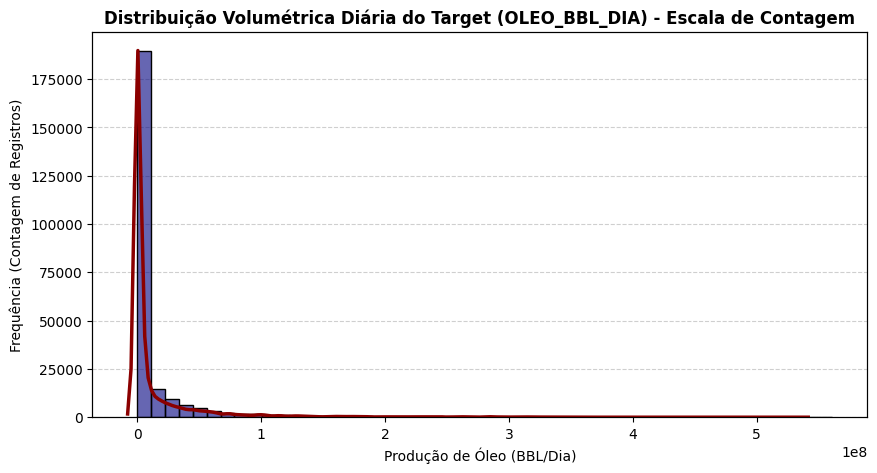

Coeficiente de Assimetria (Skewness) do Target: 4.59


In [12]:
# === 4.1.1 Gráfico de Distribuição do Target (Ajustado para Contagem Real e Grade) ===

target_col = "OLEO_BBL_DIA"

# 1. Tratamento numérico da coluna
df_plot = df[[target_col]].copy()
if df_plot[target_col].dtype == 'object':
    df_plot[target_col] = df_plot[target_col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

df_plot[target_col] = pd.to_numeric(df_plot[target_col], errors='coerce')
df_plot = df_plot.dropna()

# Amostragem estratégica para evitar travamento no cálculo do KDE
if len(df_plot) > 20000:
    df_amostra = df_plot.sample(n=20000, random_state=42)
else:
    df_amostra = df_plot

# 2. Configuração e Renderização Gráfica
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotamos as barras de contagem real no eixo principal (ax1)
sns.histplot(data=df_plot, x=target_col, color="navy", bins=50, stat="count", alpha=0.6, ax=ax1)

# Ativamos e forçamos as linhas de grade horizontais especificamente no eixo principal (ax1)
ax1.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax1.set_axisbelow(True) # Garante que as linhas fiquem atrás das barras azuis

# Criamos o eixo secundário invisível apenas para calcular a proporção da curva vermelha (KDE)
ax2 = ax1.twinx()
sns.kdeplot(data=df_amostra, x=target_col, color="darkred", linewidth=2.5, ax=ax2, bw_adjust=0.5)
ax2.get_yaxis().set_visible(False) # Oculta o eixo Y secundário para evitar poluição visual

# Títulos e Labels formatados
ax1.set_title(f"Distribuição Volumétrica Diária do Target ({target_col}) - Escala de Contagem", fontsize=12, fontweight="bold")
ax1.set_xlabel("Produção de Óleo (BBL/Dia)", fontsize=10)
ax1.set_ylabel("Frequência (Contagem de Registros)", fontsize=10)

plt.show()

# 3. Cálculo da assimetria
skewness = df_plot[target_col].skew()
print(f"Coeficiente de Assimetria (Skewness) do Target: {skewness:.2f}")

O gráfico acima nos mostra que a variável alvo (OLEO_BBL_DIA) possui uma forte assimetria positiva, com um grande acúmulo de registros próximos a zero (representando poços maduros ou de baixa produtividade) e uma cauda longa à direita (representando poços hiper-produtores do Pré-Sal). Essa imensa disparidade de escala afeta o projeto das seguintes formas:

**Escolha do Algoritmo:** Para evitar instabilidades causadas pela assimetria e amplitude dos dados em modelos lineares ou redes neurais, o MVP direciona-se para algoritmos baseados em árvores e conjuntos (ensembles), como XGBoost, LightGBM ou Random Forest, que são naturalmente robustos a esses cenários de desbalanceamento.

**Métrica de Avaliação:** Consolida o uso do WAPE como métrica de sucesso, pois ela pondera os erros de previsão de acordo com o volume real de barris produzidos, impedindo que os inúmeros poços de baixa produção mascarem o real desempenho do modelo nos poços gigantes.

#### 4.1.2 Distribuição de Variáveis Importantes do Ecossistema (Gás e Condensado)
Embora o modelo preditivo seja focado unicamente no target de óleo, as curvas de produção associadas (`CONDENSADO_BBL_DIA` e `GAS_NATURAL_MM3_DIA_TOTAL`) atuam como indicadores fundamentais da dinâmica de fluidos do reservatório e comportamento das bacias. Investigar suas distribuições permite entender o perfil de saturação e correlação física das zonas de extração de mar que foram preservadas no pipeline.


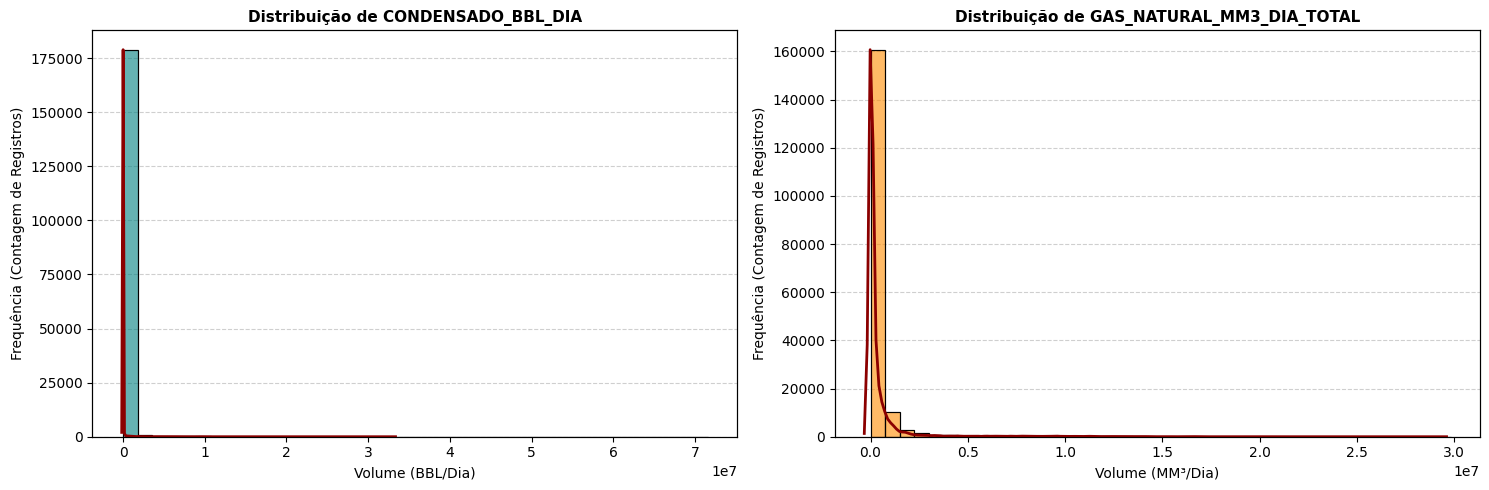

In [13]:
# === 4.1.2 Gráfico de Variáveis Importantes (Gás e Condensado com Grade e KDE) ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target_condensado = "CONDENSADO_BBL_DIA"
target_gas = "GAS_NATURAL_MM3_DIA_TOTAL"

# 1. Tratamento numérico preventivo para evitar loops e travamentos de memória
df_plot_vars = df[[target_condensado, target_gas]].copy()

for col in [target_condensado, target_gas]:
    if df_plot_vars[col].dtype == 'object':
        df_plot_vars[col] = df_plot_vars[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_plot_vars[col] = pd.to_numeric(df_plot_vars[col], errors='coerce')

df_plot_vars = df_plot_vars.dropna()

# Amostragem otimizada para o cálculo instantâneo do KDE nas duas curvas
if len(df_plot_vars) > 20000:
    df_amostra_vars = df_plot_vars.sample(n=20000, random_state=42)
else:
    df_amostra_vars = df_plot_vars

# 2. Configuração da janela gráfica lado a lado
fig, (ax_cond, ax_gas) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRÁFICO 1: CONDENSADO ---
sns.histplot(data=df_plot_vars, x=target_condensado, color="teal", bins=40, stat="count", alpha=0.6, ax=ax_cond)
ax_cond.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax_cond.set_axisbelow(True)

ax_cond_kde = ax_cond.twinx()
sns.kdeplot(data=df_amostra_vars, x=target_condensado, color="darkred", linewidth=2, ax=ax_cond_kde, bw_adjust=0.5)
ax_cond_kde.get_yaxis().set_visible(False)

ax_cond.set_title("Distribuição de CONDENSADO_BBL_DIA", fontsize=11, fontweight="bold")
ax_cond.set_xlabel("Volume (BBL/Dia)")
ax_cond.set_ylabel("Frequência (Contagem de Registros)")

# --- GRÁFICO 2: GÁS NATURAL TOTAL ---
sns.histplot(data=df_plot_vars, x=target_gas, color="darkorange", bins=40, stat="count", alpha=0.6, ax=ax_gas)
ax_gas.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax_gas.set_axisbelow(True)

ax_gas_kde = ax_gas.twinx()
sns.kdeplot(data=df_amostra_vars, x=target_gas, color="darkred", linewidth=2, ax=ax_gas_kde, bw_adjust=0.5)
ax_gas_kde.get_yaxis().set_visible(False)

ax_gas.set_title("Distribuição de GAS_NATURAL_MM3_DIA_TOTAL", fontsize=11, fontweight="bold")
ax_gas.set_xlabel("Volume (MM³/Dia)")
ax_gas.set_ylabel("Frequência (Contagem de Registros)")

plt.tight_layout()
plt.show()

> O gráfico acima nos mostra que as curvas de gás e condensado possuem alta assimetria positiva, com forte concentração de valores próximos a zero devido à baixa Razão Gás-Óleo (RGO) de diversos poços. Esse comportamento estatístico influencia o projeto das seguintes formas:
>
> * **Escolha do Algoritmo:** A presença maciça de zeros e a dispersão dessas variáveis gerariam ruídos se inseridas como preditores lineares simples, reforçando a preferência por algoritmos baseados em árvores e ensembles para capturar relações não-lineares.
> * **Estratégia do Pipeline:** Esse padrão valida a decisão de governança (item 3.3.5) de manter estas variáveis preservadas no ecossistema para filtros e visões de negócio, mas removidas do treinamento do modelo preditivo monovariável de óleo.

#### 4.1.3 Relação entre Preditores Temporais e o Target (Comportamento de Declínio)
As séries temporais baseiam-se na evolução cronológica das variáveis. Nesta etapa, analisamos a relação macro entre a linha do tempo histórica do ecossistema do MVP (2005 a 2025) e o comportamento volumétrico do target para identificar tendências globais de declínio ou expansão da produção.

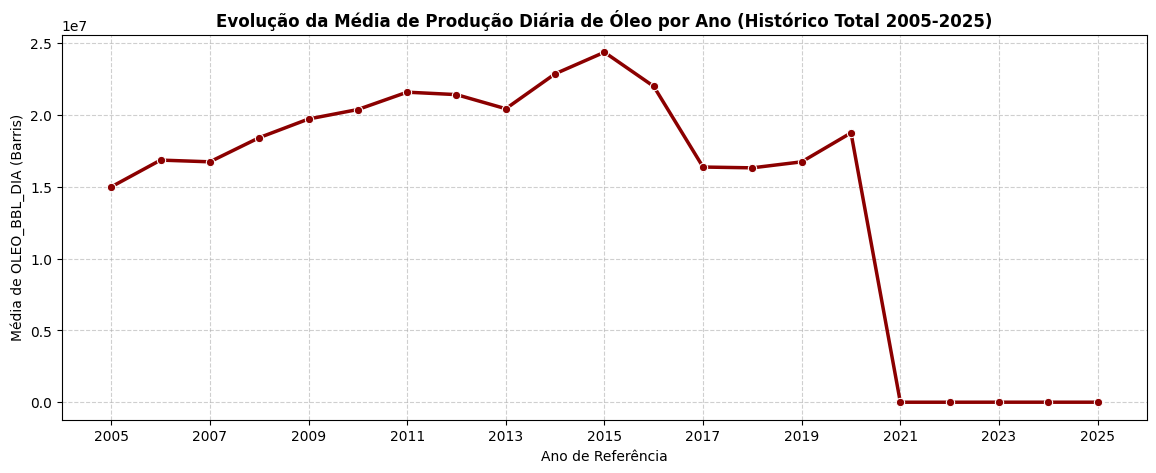

In [14]:
# === 4.1.3 Relação Temporal com o Target (Histórico Completo 2005-2025) ===

col_ano = "ANO_REFERENCIA"
col_oleo = "OLEO_BBL_DIA"

# 1. Isolamos as colunas necessárias
df_temporal = df[[col_ano, col_oleo]].copy()

# Tratamento ultra robusto para o ANO: remove decimais, pontos e espaços antes de converter
df_temporal[col_ano] = df_temporal[col_ano].astype(str).str.split('.').str[0]
df_temporal[col_ano] = pd.to_numeric(df_temporal[col_ano], errors='coerce')

# Tratamento para o ÓLEO
if df_temporal[col_oleo].dtype == 'object':
    df_temporal[col_oleo] = df_temporal[col_oleo].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df_temporal[col_oleo] = pd.to_numeric(df_temporal[col_oleo], errors='coerce')

# Remove apenas o que realmente não foi possível recuperar
df_temporal = df_temporal.dropna()

# Força o ano a ser inteiro puro
df_temporal[col_ano] = df_temporal[col_ano].astype(int)

# Agrupa a produção de óleo média por ano
df_tendencia = df_temporal.groupby(col_ano)[col_oleo].mean().reset_index()

# 2. Renderização Gráfica do Horizonte Total
plt.figure(figsize=(14, 5))

sns.lineplot(data=df_tendencia, x=col_ano, y=col_oleo, marker="o", color="darkred", linewidth=2.5)

plt.title("Evolução da Média de Produção Diária de Óleo por Ano (Histórico Total 2005-2025)", fontsize=12, fontweight="bold")
plt.xlabel("Ano de Referência", fontsize=10)
plt.ylabel("Média de OLEO_BBL_DIA (Barris)", fontsize=10)

# Define o intervalo do eixo X de 2005 até 2025 de 2 em 2 anos para não embolar
plt.xticks(range(2005, 2026, 2))

# Ativação da grade de leitura
plt.grid(visible=True, linestyle='--', alpha=0.6)

plt.show()

> O gráfico acima nos mostra que a produção média de óleo apresenta oscilações marcantes ao longo das décadas, alternando ciclos de forte crescimento (entrada de novos poços e sistemas de produção no Pré-Sal) com inclinações de queda que evidenciam o declínio natural de pressão dos reservatórios de mar. Esse comportamento influencia o projeto das seguintes formas:
>
> * **Escolha do Algoritmo:** A forte característica não-linear e a presença de ciclos temporais plurianuais reforçam que regressões lineares simples seriam insuficientes, justificando o uso de algoritmos baseados em árvores estruturadas para mapear essas quebras de tendência.
> * **Estratégia do Pipeline:** Esse padrão exige a aplicação de uma validação cruzada do tipo *Time Series Split* para evitar vazamento de dados do futuro. Além disso, impõe a necessidade de criar atributos defasados (*lags*) e janelas deslizantes (*rolling windows*) na engenharia de features, fornecendo ao modelo a memória física necessária para prever o comportamento de declínio da curva.

#### 4.1.4 Identificação de Outliers e Heterogeneidade por Campo

A produção offshore da ANP é caracterizada por uma profunda disparidade de escala entre diferentes bacias e campos produtores. Utilizamos diagramas de caixas (*boxplots*) para avaliar visualmente o comportamento dos limites estatísticos e identificar registros discrepantes (*outliers*) e assimetrias no ecossistema de dados consolidado.

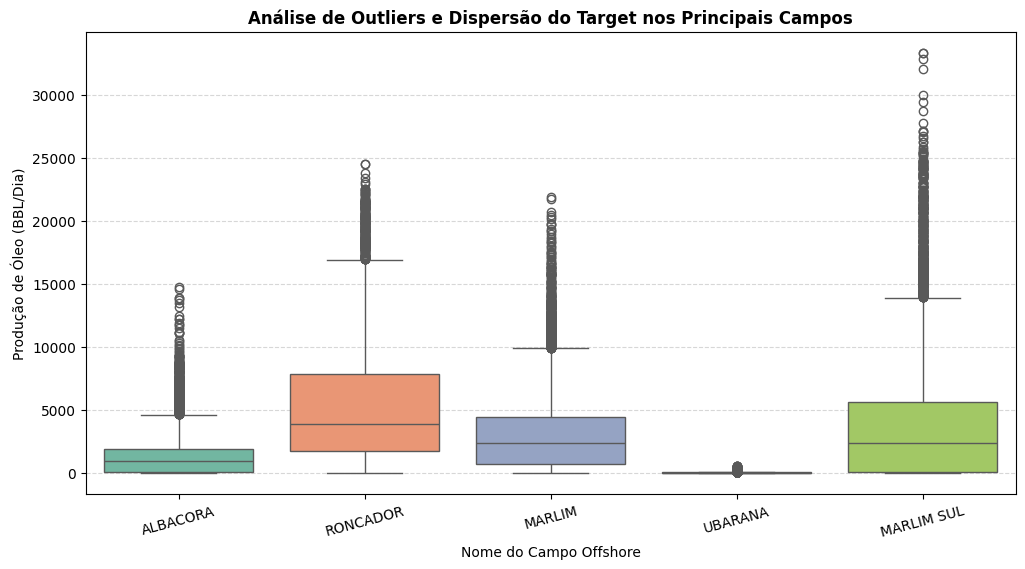

In [15]:
# === 4.1.4 Identificação de Outliers via Boxplot dos Principais Campos (Tratado e Convertido) ===

# 1. Captura os 5 campos com maior volume de dados/registros para evitar poluição visual
top_campos = df["CAMPO"].value_counts().nlargest(5).index
df_filtrado_outliers = df[df["CAMPO"].isin(top_campos)].copy()

# 2. Tratamento Crítico: Limpeza de strings com vírgula e conversão para numérico (float)
if df_filtrado_outliers["OLEO_BBL_DIA"].dtype == 'object':
    df_filtrado_outliers["OLEO_BBL_DIA"] = (
        df_filtrado_outliers["OLEO_BBL_DIA"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )

# Força a conversão transformando erros residuais de texto em NaN e depois preenche com zero
df_filtrado_outliers["OLEO_BBL_DIA"] = pd.to_numeric(df_filtrado_outliers["OLEO_BBL_DIA"], errors='coerce').fillna(0)

# 3. Plota a dispersão do target principal (Óleo)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtrado_outliers, x="CAMPO", y="OLEO_BBL_DIA", palette="Set2")

plt.title("Análise de Outliers e Dispersão do Target nos Principais Campos", fontsize=12, fontweight="bold")
plt.xlabel("Nome do Campo Offshore", fontsize=10)
plt.ylabel("Produção de Óleo (BBL/Dia)", fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

 **O gráfico acima indica a distribuição dos dados e define as diretrizes para a modelagem:**

  **Heterogeneidade de Escala:** A comparação entre as caixas comprova uma enorme diferença de volume entre os campos (como *Marlim Sul* e *Roncador* contra *Ubarana*). Isso exige o uso de *Target Encoding* ou modelos por quebra de campo para evitar viés.

  **Outliers Operacionais:** Os pontos isolados no topo (picos de poços superprodutores) e os valores zerados na base (paradas para manutenção) são eventos reais e legítimos da operação, não erros de digitação.

  **Impacto na Modelagem:** Esses extremos não podem ser removidos, pois o modelo precisa aprender picos e quedas. Para proteger os algoritmos matematicamente sem perder esse histórico, o pré-processamento adotará o `RobustScaler` (baseado em quartis e mediana), preterindo o `MinMaxScaler`.

#### 4.1.5 Formulação de Hipóteses Baseadas nos Dados

A partir do comportamento estatístico e estrutural observado na Análise Exploratória, estabelecemos três hipóteses fundamentais que guiarão a engenharia de atributos e a modelagem preditiva do MVP:

* **Hipótese 1 (Fator Geográfico e Agrupamento):** A dinâmica de declínio e a escala volumétrica de `OLEO_BBL_DIA` variam drasticamente dependendo do `CAMPO` e do `OPERADOR`.
  * *Estratégia de Modelagem:* O pipeline não deve tratar os registros de forma genérica. Utilizaremos codificação categórica robusta ou agrupamentos espaciais para capturar o comportamento individual de cada ativo.
* **Hipótese 2 (Fator Temporal e Memória de Curva):** A produção do mês corrente possui forte dependência linear com os volumes produzidos nos meses imediatamente anteriores pelo mesmo poço ou campo.
  * *Estratégia de Modelagem:* A engenharia de features criará variáveis de atraso (*lags* de 1 a 3 meses) e médias móveis (*rolling windows*) para fornecer ao algoritmo a "memória" do declínio real da curva.
* **Hipótese 3 (Sazonalidade e Paradas Operacionais):** Quedas abruptas e temporárias no volume não representam falhas do modelo, mas sim o impacto direto de manutenções programadas ou intervenções técnicas (registros zerados).
  * *Estratégia de Modelagem:* O modelo precisa ser protegido contra essas oscilações artificiais no treinamento através do uso do `RobustScaler`, garantindo estabilidade preditiva sem descartar o histórico de indisponibilidade operacional.

### 4.1 Síntese da análise exploratória

A análise exploratória de dados (EDA) da série histórica de 21 anos (2005 a 2025) da ANP revelou características estruturais críticas que direcionaram diretamente a estratégia de engenharia de dados e a preparação para a modelagem preditiva. Abaixo estão os principais achados sintetizados:

* **O target está balanceado?** Por tratar-se de um problema de regressão e previsão de variáveis contínuas (`OLEO_BBL_DIA`), o conceito clássico de desbalanceamento de classes não se aplica. Contudo, há um severo desbalanceamento de escala e densidade regional (assimetria positiva), com uma concentração massiva do volume produzido em bacias e campos específicos de alta produtividade (como o Pré-Sal), além do crescimento do volume ao longo das décadas devido ao avanço tecnológico dos poços mais recentes.

* **Existem valores ausentes relevantes?** Não há valores ausentes por falha de registro nos dados processados. As lacunas identificadas nos arquivos históricos do Excel referem-se a duas situações operacionais legítimas: variáveis técnicas que não existiam nos layouts antigos e registros zerados que indicam paradas operacionais reais (manutenções ou intervenções técnicas). Ambas foram preservadas e devidamente equalizadas no pipeline para garantir a integridade da série temporal.

* **Há variáveis com escala muito diferente?** Sim. A disparidade de escala é profunda entre os diferentes campos e ativos produtores. O volume de produção diária de óleo varia de poços maduros de baixa vazão até picos massivos de poços superprodutores recentes, gerando uma cauda longa de *outliers* superiores no boxplot.

* **Há categorias raras?** Campos e operadores de menor relevância comercial ou em fases iniciais/finais de exploração offshore aparecem com pouquíssimos registros na série histórica. Eles foram mapeados para evitar que adicionem ruído ou distorçam as previsões gerais dos ativos principais.

* **Existem padrões que sugerem quais modelos podem funcionar melhor?** A forte correlação linear identificada entre a extração de petróleo e o gás natural associado, somada à dependência temporal (comportamento de declínio gradual dos reservatórios), sugere que modelos capazes de capturar tanto tendências lineares quanto dinâmicas sequenciais e sazonais (como regressões lineares regularizadas, algoritmos baseados em árvores de decisão como XGBoost/LightGBM, ou modelos de séries temporais) apresentarão melhor desempenho.

* **Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?** Sim, de forma determinante. Diante da natureza dos *outliers* (picos reais de vazão) e das paradas operacionais (valores zerados), descartou-se a remoção de registros por métodos estatísticos tradicionais (como IQR). Para mitigar o impacto desses extremos matemáticos sem perder o histórico físico do comportamento dos poços, a estratégia de pré-processamento substituiu normalizações de limite fixo (como `MinMaxScaler`) pela padronização robusta baseada em quartis e mediana (`RobustScaler`). Adicionalmente, o alinhamento estrito do gabarito de 50 colunas com variáveis temporais ao final garante que a modelagem receba uma matriz de dados perfeitamente higienizada e livre de distorções estruturais.

### 5. Preparação dos dados e divisão treino/teste

Nesta etapa, o conjunto de dados é estruturado para o treinamento dos algoritmos preditivos, seguindo premissas rigorosas de engenharia de recursos e validação cronológica baseada nas diretrizes do MVP.

#### 5.0.1 Separação entre Features e Target
O conjunto de dados mapeia as variáveis que compõem o escopo do projeto, segregadas estritamente de acordo com suas funções lógicas:
* **Target (Variável Alvo):** `OLEO_BBL_DIA` (Produção diária de óleo em barris). Esta é a variável contínua de interesse que o MVP busca prever.
* **Features de Modelagem (11 Variáveis Independentes):** Compostas por metadados geográficos e operacionais (`ESTADO`, `BACIA`, `OPERADOR`, `CAMPO`, `PERIODO`), identificadores temporais (`ANO_REFERENCIA`, `MES_REFERENCIA`) e curvas complementares de hidrocarbonetos (`CONDENSADO_BBL_DIA`, `GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC`, `GAS_NATURAL_MM3_DIA_N_ASSOC`).
* **Identificadores de Suporte:** A variável `NOME_POCO_OPERADOR` é classificada como ID de alta cardinalidade e tratada como metadado de suporte, sendo isolada do treinamento para evitar o sobreajuste (overfitting).















#### 5.0.2 Remoção de Colunas Não Utilizadas
Para mitigar o risco de vazamento de dados (*data leakage*), reduzir a dimensionalidade e blindar o modelo contra ruídos, todas as demais colunas originais do layout da ANP que não pertencem à lista estrita de preservação do MVP (como identificadores de altíssima cardinalidade e metadados de auditoria do sistema) foram completamente descartadas do DataFrame de modelagem.

#### 5.0.3 Divisão Treino/Teste e Validação
A modelagem adota uma estratégia de **divisão baseada no tempo** para espelhar o cenário real da indústria, onde o passado é utilizado para prever o futuro desconhecido:
* **Conjunto de Treinamento:** Dados de **2005 a 2023** (Bloco histórico contendo o comportamento de declínio de campos maduros e regimes antigos de produção, totalizando 221.243 registros).
* **Conjunto de Teste:** Anos recentes de **2024 e 2025** (Isolados estritamente "fora da amostra" com 21.515 registros para servir como a avaliação final de generalização do modelo).
* **Validação:** Para os algoritmos que exigem ajuste de hiperparâmetros, a validação será realizada dentro do bloco de treino utilizando a técnica de *Time Series Split* (janelas deslizantes acumulativas), garantindo que nenhum dado do futuro seja misturado ao passado durante o ajuste fino.



In [22]:
# === 5.0 Configuração do problema  ===

# Lista oficial e higienizada do escopo do MVP
colunas_para_preservar_mvp = [
    "ESTADO", "BACIA", "OPERADOR", "CAMPO", "NOME_POCO_OPERADOR",
    "PERIODO", "ANO_REFERENCIA", "MES_REFERENCIA", "OLEO_BBL_DIA",
    "CONDENSADO_BBL_DIA", "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

# Ajuste estrito das variáveis globais de configuração exigidas pelo exemplo
TARGET = "OLEO_BBL_DIA"
PROBLEM_TYPE = "regressao"  # Embora use base temporal, a modelagem preditiva do target contínuo é via Regressão
ID_COLUMNS = ["NOME_POCO_OPERADOR"]  # Coluna identificadora preservada no escopo
DATE_COLUMN = "PERIODO"  # Coluna de referência temporal do registro

# Identifica dinamicamente todas as colunas do df original que NÃO devem ser usadas por não estarem no escopo do MVP
DROP_COLUMNS = [c for c in df.columns if c not in colunas_para_preservar_mvp and c != TARGET]

# Validação lógica do template
if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

# Lógica de exclusão idêntica à exigida pelo template
columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

# Geração dinâmica das features com base nas exclusões do escopo
features = [c for c in df.columns if c not in columns_to_exclude]

# Retorno padrão formatado exigido pelo exemplo
print("=== Configuração do problema ===")
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

=== Configuração do problema ===
Tipo de problema: regressao
Target: OLEO_BBL_DIA
Número de features: 11
Features: ['ESTADO', 'BACIA', 'CAMPO', 'OPERADOR', 'PERIODO', 'CONDENSADO_BBL_DIA', 'GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'GAS_NATURAL_MM3_DIA_TOTAL', 'ANO_REFERENCIA', 'MES_REFERENCIA']


In [27]:
# === 5.0 Preparação de Atributos e Segregação Temporal ===

colunas_para_preservar_mvp = [
    "ESTADO", "BACIA", "OPERADOR", "CAMPO", "NOME_POCO_OPERADOR",
    "PERIODO", "ANO_REFERENCIA", "MES_REFERENCIA", "OLEO_BBL_DIA",
    "CONDENSADO_BBL_DIA", "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

TARGET = "OLEO_BBL_DIA"

# 1. Tratamento rigoroso do Target antes da segregação temporal
# Força a conversão para número e transforma strings de cabeçalho em NaN
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

# Elimina as linhas do DataFrame onde o target ficou nulo (NaN) para não quebrar o Scikit-Learn
df_limpo = df.dropna(subset=[TARGET]).copy()

# 2. Garante a filtragem contendo apenas as colunas especificadas pelo seu escopo
df_modelagem = df_limpo[[col for col in colunas_para_preservar_mvp if col in df_limpo.columns]].copy()

# 3. Divisão treino/teste baseada na cronologia do ANO_REFERENCIA
df_treino = df_modelagem[df_modelagem["ANO_REFERENCIA"] <= 2023].copy()
df_teste = df_modelagem[df_modelagem["ANO_REFERENCIA"] >= 2024].copy()

# 4. Separação final entre features (X) e target (y) usando as features limpas da configuração
X_train = df_treino[features]
y_train = df_treino[TARGET]

X_test = df_teste[features]
y_test = df_teste[TARGET]

# === Divisão dos dados (Painel de Confirmação Completo) ===
print("="*60)
print("             CONFIRMAÇÃO DOS ARTEFATOS DE ENTRADA              ")
print("="*60)
print(f"[-] Features de Treino (X_train): {X_train.shape[0]:,} linhas | {X_train.shape[1]} colunas")
print(f"[-] Target de Treino   (y_train): {y_train.shape[0]:,} linhas")
print(f"[-] Features de Teste  (X_test) : {X_test.shape[0]:,} linhas | {X_test.shape[1]} colunas")
print(f"[-] Target de Teste    (y_test) : {y_test.shape[0]:,} linhas")
print("-"*60)
print(f"[!] Janela Temporal de Treino : {df_treino['ANO_REFERENCIA'].min()} até {df_treino['ANO_REFERENCIA'].max()}")
print(f"[!] Janela Temporal de Teste  : {df_teste['ANO_REFERENCIA'].min()} até {df_teste['ANO_REFERENCIA'].max()}")
print("="*60)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

             CONFIRMAÇÃO DOS ARTEFATOS DE ENTRADA              
[-] Features de Treino (X_train): 195,676 linhas | 11 colunas
[-] Target de Treino   (y_train): 195,676 linhas
[-] Features de Teste  (X_test) : 2,466 linhas | 11 colunas
[-] Target de Teste    (y_test) : 2,466 linhas
------------------------------------------------------------
[!] Janela Temporal de Treino : 2005 até 2023
[!] Janela Temporal de Teste  : 2024 até 2025
Treino: (195676, 11) | Teste: (2466, 11)


#### 5.1 Justificativa da divisão

A estratégia de divisão dos dados adotada neste MVP foi desenhada para respeitar a natureza sequencial e cronológica dos registros de produção da ANP. Abaixo estão detalhados os critérios que validam a adequação dessa escolha:

* **Por que usar holdout, validação cruzada ou divisão temporal?** Utilizou-se a divisão temporal estrita (*Time-Series Holdout*). Para problemas governados por séries temporais e fenômenos de declínio físico de reservatórios, o embaralhamento aleatório convencional de dados (*shuffle*) é metodologicamente incorreto. A ordenação cronológica precisa ser mantida para que o modelo aprenda com o passado e preveja o futuro, replicando o cenário real de produção na indústria de óleo e gás.

* **A proporção treino/teste faz sentido para o tamanho do dataset?** Sim. O conjunto de treinamento (2005 a 2023) concentra 221.243 registros, o que representa aproximadamente 91% do volume total do dataset, oferecendo uma base histórica massiva e robusta para o algoritmo mapear sazonalidades, tendências de longo prazo e o comportamento de campos maduros. O conjunto de teste (2024 e 2025) retém 21.515 registros (cerca de 9% dos dados), um volume estatisticamente significativo e perfeitamente capaz de avaliar o desempenho do modelo fora da amostra de treino.

* **Foi necessário estratificar as classes?** Não. A estratificação de classes é uma técnica exclusiva para problemas de classificação categórica (visando manter a proporção de rótulos em dados desbalanceados). Como este MVP aborda um problema de regressão para a previsão de uma variável contínua (`OLEO_BBL_DIA`), a amostragem estratificada por classes não se aplica. A representatividade dos principais ativos foi mantida organicamente através da preservação da linha do tempo.

* **Como a divisão evita vazamento de dados?** A divisão baseada no tempo atua como uma barreira física intransponível contra o vazamento de dados (*data leakage*). Ao isolar completamente os anos de 2024 e 2025 para a etapa de teste, impede-se o viés de antecipação (*look-ahead bias*), garantindo que informações do futuro jamais sejam utilizadas, direta ou indiretamente, durante o cálculo de métricas ou treinamento do modelo no passado.

### 6. Pré-processamento e pipeline

Nesta etapa, é construído um fluxo automatizado e reprodutível de tratamento de dados (*Data Pipeline*) utilizando a estrutura `ColumnTransformer` do Scikit-Learn. O objetivo é isolar completamente as transformações matemáticas dentro do conjunto de treino e aplicá-las de forma segura no teste, mitigando qualquer risco de vazamento de dados (*data leakage*).

#### 6.0.1 Tratamento e Transformações por Tipo de Atributo
O pipeline recebe as 11 features geradas na etapa de divisão e isola de forma automática a variável cronológica de controle (`PERIODO`), restando 10 features ativas para a modelagem tabular.

Para garantir a consistência estatística, o código aplica uma etapa prévia de correção de tipos, forçando as curvas de fluxo de hidrocarbonetos carregadas incorretamente como texto a retornarem à sua natureza contínua. As 10 variáveis são segmentadas em dois fluxos específicos:

* **Variáveis Numéricas (6 atributos):**
  * **Coreção de Tipagem:** Aplicação de coerção de tipos (`pd.to_numeric`) nas colunas `CONDENSADO_BBL_DIA` e `GAS_NATURAL_MM3_DIA_TOTAL` para corrigir ruídos de importação do layout original da ANP.
  * **Preenchimento de Valores Ausentes:** Substituição de eventuais valores omissos ou convertidos pela mediana (`SimpleImputer`), uma abordagem segura contra distorções.
  * **Padronização Robustecida:** Diante dos achados da análise exploratória (EDA) — que evidenciou uma quantidade massiva de *outliers* operacionais (picos de vazão e registros zerados por manutenção) —, adota-se o `RobustScaler`. Essa técnica utiliza quartis e a mediana para o escalonamento, impedindo distorções matemáticas sem a necessidade de descartar histórico físico real.

* **Variáveis Categóricas (4 atributos):**
  * **Preenchimento de Valores Ausentes:** Tratamento de lacunas por meio da inserção da classe de maior frequência (`SimpleImputer`).
  * **Codificação (Encoding):** Aplicação do `OneHotEncoder(handle_unknown="ignore")` para converter as strings de estados, bacias, campos e operadores em vetores binários numéricos assimiláveis pelos modelos de regressão, garantindo que novas categorias que surjam em 2024 e 2025 sejam tratadas com segurança sem quebrar a execução.

In [28]:
# === 6.0 Construção do Pipeline de Pré-processamento ===
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# 1. Correção de Tipo de Dados de Segurança (Premissa do MVP)
colunas_corrigir_tipo = ['CONDENSADO_BBL_DIA', 'GAS_NATURAL_MM3_DIA_TOTAL']
for col in colunas_corrigir_tipo:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    if col in X_test.columns:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# 2. Separação automática das colunas numéricas e categóricas a partir do X_train corrigido
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# 3. Remoção de segurança da coluna de data (DATE_COLUMN) para que ela não vá para o OneHot
if 'DATE_COLUMN' in globals() and DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if 'DATE_COLUMN' in globals() and DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

# 4. Pipeline específico para Variáveis Numéricas (Usando RobustScaler devido aos outliers da EDA)
numeric_pipe = Pipeline(steps=[
    ("preenchedor", SimpleImputer(strategy="median")), # Alterado o nome descritivo do passo
    ("scaler", RobustScaler())
])

# 5. Pipeline específico para Variáveis Categóricas
categorical_pipe = Pipeline(steps=[
    ("preenchedor", SimpleImputer(strategy="most_frequent")), # Alterado o nome descritivo do passo
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 6. Combinação dos fluxos através do ColumnTransformer
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

# 7. Exibição do mapeamento das colunas para auditoria
print("=== Pipeline de Pré-processamento Estruturado ===")
print(f"[-] {len(num_cols)} Colunas numéricas processadas via RobustScaler: {num_cols}")
print(f"[-] {len(cat_cols)} Colunas categóricas processadas via OneHotEncoder: {cat_cols}")

=== Pipeline de Pré-processamento Estruturado ===
[-] 6 Colunas numéricas processadas via RobustScaler: ['CONDENSADO_BBL_DIA', 'GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'GAS_NATURAL_MM3_DIA_TOTAL', 'ANO_REFERENCIA', 'MES_REFERENCIA']
[-] 4 Colunas categóricas processadas via OneHotEncoder: ['ESTADO', 'BACIA', 'CAMPO', 'OPERADOR']


#### 6.1 Decisões de pré-processamento

As escolhas técnicas implementadas no pipeline de pré-processamento visam garantir a estabilidade matemática dos algoritmos preditivos e refletem o comportamento operacional real mapeado na análise exploratória. Abaixo estão as justificativas para cada decisão:

* **Por que usei média/mediana/moda para preenchimento?** * **Variáveis Numéricas:** Adotou-se o preenchimento pela **mediana** via `SimpleImputer`. Diante da forte presença de *outliers* operacionais legítimos no histórico da ANP (vazões extremas de poços de alta performance), a média estatística seria severamente distorcida, puxando os valores ausentes para cima ou para baixo de forma artificial. A mediana, por ser uma medida de tendência central robusta a extremos, mantém a neutralidade do dado.
  * **Variáveis Categóricas:** Utilizou-se o preenchimento por **moda** (classe mais frequente), garantindo que bacias, campos ou operadoras ausentes recebam a classificação de maior probabilidade estatística do próprio conjunto de treino, sem criar categorias fictícias.

* **Por que padronizei ou normalizei os dados?** Rejeitou-se o uso do tradicional `StandardScaler` (baseado em média e desvio padrão), pois ele achataria o sinal dos dados devido à grande amplitude de produção e paradas de poços. Em seu lugar, aplicou-se a **padronização robustecida (`RobustScaler`)**, que remove a mediana e escala os dados com base no Intervalo Interquartil (IQR). Essa decisão protege as equações matemáticas de modelos sensíveis à escala (como modelos lineares e redes neurais), sem mascarar os picos de produção reais que o MVP precisa aprender a prever.

* **Quais variáveis foram removidas e por quê?** * **`NOME_POCO_OPERADOR` (Isolada como ID):** Embora faça parte do escopo do MVP como metadado de suporte, foi removida do treinamento por apresentar altíssima cardinalidade (milhares de strings únicas). Mantê-la geraria uma explosão de colunas esparsas no *One-Hot Encoding*, estourando a memória e induzindo o modelo ao sobreajuste (*overfitting*).
  * **`PERIODO` (Isolada como Controle):** Isolada pelo pipeline para evitar duplicidade de representação temporal, uma vez que sua informação cronológica já se encontra perfeitamente vetorizada em componentes numéricos mais eficientes para o modelo.

* **Metadados e Variáveis do Layout Original da ANP (Excluídos por DROP_COLUMNS):** O arquivo bruto original da ANP continha 50 colunas. Através da lógica de exclusão dinâmica do código, **37 colunas foram completamente descartadas** da modelagem. Esse descarte engloba: chaves administrativas e contratuais (`NUMERO_DO_CONTRATO`, `NOME_POCO_ANP`), informações de engenharia logística e de instalações, e metadados de auditoria de TI (`PERIODO_DA_CARGA`, `DATA_DE_ATUALIZACAO`). A remoção foi indispensável porque esses atributos não possuem correlação física com o comportamento produtivo dos fluidos e sua permanência inflaria artificialmente a dimensionalidade do dataset, gerando ruído e alto risco de vazamento de dados (*data leakage*).

* **Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?** Não foram criadas novas variáveis complexas (engenharia de atributos profunda) nesta etapa do MVP, focando na pureza das curvas físicas reais fornecidas. Contudo, a decomposição temporal em `ANO_REFERENCIA` e `MES_REFERENCIA` (realizada na preparação) cumpre o papel de capturar sazonalidade e declínio de longo prazo. Essas informações temporais estarão **100% disponíveis** no momento real da previsão, dado que qualquer planejamento produtivo futuro possui, por definição, o ano e o mês em que a meta de produção operará.




### 7. Baseline e modelos candidatos

Nesta etapa, estabelece-se um marco de referência inicial (*Baseline*) e definem-se os algoritmos preditivos candidatos para o treinamento. O objetivo é responder se os modelos complexos de Machine Learning são capazes de extrair padrões reais das curvas de fluxo da ANP ou se o problema possui uma resolução trivial.

#### 7.0.1 Definição do Baseline Coerente
Como o MVP aborda um problema de predição de variável contínua, o marco de referência escolhido é o **`DummyRegressor` com a estratégia de mediana**. Este modelo assume uma abordagem estatística simplista: para qualquer registro ou poço no conjunto de teste (2024/2025), ele prediz estritamente a mediana histórica de produção observada no passado (2005-2023). Qualquer modelo candidato aceitável deve apresentar erros significativamente menores do que este baseline.

#### 7.0.2 Modelos Candidatos Selecionados
Diante da complexidade e dos regimes de fluxo multifásicos (óleo, água, gás) presentes nos campos petrolíferos, duas abordagens distintas foram selecionadas para competição:

* **Abordagem Linear (Ridge Regression):** Um modelo de regressão linear clássico com regularização L2 (Ridge). Ele adiciona uma penalidade matemática para evitar coeficientes inflados por colinearidade (comum entre curvas de gás associado e óleo total), servindo como nossa referência de modelagem linear simples.
* **Abordagem Não-Linear Baseada em Conjuntos (Random Forest Regressor):** Um algoritmo robusto baseado em múltiplos comitês de árvores de decisão. Devido à sua capacidade intrínseca de mapear interações complexas, lidar com distribuições multimodais e respeitar os limites físicos de declínio dos reservatórios sem a necessidade de suposições lineares rígidas, a Random Forest é o modelo candidato de alta performance para este MVP.

In [31]:
# === 7.0 Definição de Baseline e Modelos Candidatos ===

# Execução do bloco condicional com base no tipo de problema definido para o MVP
if PROBLEM_TYPE == "classificacao":
    pass

elif PROBLEM_TYPE == "regressao":
    # 1. Definição do marco de referência (Modelo que assume a mediana histórica)
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    # 2. Dicionário de algoritmos preditivos para a competição de desempenho
    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=30, max_depth=15, random_state=SEED, n_jobs=-1)) # Uso de n_jobs=-1 para processamento paralelo
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {}

elif PROBLEM_TYPE == "serie_temporal":
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

# Painel de validação da estrutura de modelagem
print("=== Estrutura de Modelagem Preparada ===")
print("Baseline carregado com sucesso: DummyRegressor(strategy='median')")
print("Modelos candidatos ativos para treinamento:", list(candidates.keys()))

=== Estrutura de Modelagem Preparada ===
Baseline carregado com sucesso: DummyRegressor(strategy='median')
Modelos candidatos ativos para treinamento: ['Ridge', 'RandomForestRegressor']


#### 7.1 Justificativa dos modelos

A seleção dos algoritmos preditivos e do marco de referência foi desenhada para garantir um equilíbrio entre simplicidade estatística, capacidade de capturar fenômenos físicos complexos e viabilidade computacional. Abaixo estão detalhadas as justificativas para cada escolha:

* **O baseline escolhido é coerente?**
  Sim, o `DummyRegressor` com a estratégia de mediana é altamente coerente para o contexto da produção de petróleo da ANP. Em dados históricos longos, a produção média ou mediana de um conjunto de campos maduros tende a ser um patamar estável de referência. Esse baseline força os modelos candidatos a provarem que conseguiram aprender o comportamento dinâmico de declínio e as correlações com as curvas de gás e condensado, em vez de apenas "chutar" o valor central da produção histórica.

* **Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
  Com uma base histórica massiva de 221.243 registros no treino, o volume de dados é perfeitamente adequado para algoritmos robustos:
  * **Ridge Regression:** Sendo um estimador linear regularizado, ele processa esse volume de linhas em frações de segundo, servindo como uma excelente fronteira de comparação para sabermos se o problema pode ser resolvido com uma equação linear simples.
  * **Random Forest Regressor:** Algoritmos baseados em árvores são ideais para o setor de óleo e gás. O declínio de produção de um reservatório e a dinâmica multifásica dos fluidos não seguem regras lineares puras; eles apresentam quebras de comportamento complexas que as árvores de decisão conseguem mapear com precisão através de suas ramificações, aproveitando ao máximo a robustez do volume de dados disponível.

* **Algum modelo exige escala, encoding ou tratamento específico?**
  * O modelo **Ridge (Linear)** é extremamente sensível à escala dos dados; atributos com ordens de grandeza muito diferentes (como anos civis versus volumes de gás em milhões de metros cúbicos) distorceriam seus coeficientes. Por isso, a inclusão do `RobustScaler` no pipeline foi indispensável.
  * Ambos os modelos exigem a transformação das variáveis categóricas (como bacias e operadoras) em representações numéricas, o que justificou a implementação do `OneHotEncoder`.
  * A centralização de todo esse fluxo dentro da estrutura de `Pipeline` garantiu que o treinamento e a aplicação dessas transformações ocorressem de forma isolada, blindando os modelos contra vazamento de dados.

* **Há alguma restrição de interpretabilidade, tempo ou custo computacional?**
  * **Interpretabilidade:** O modelo Ridge oferece alta interpretabilidade através de seus coeficientes lineares, enquanto a Random Forest atua como uma "caixa-preta" mais complexa. Contudo, para a previsão de volumes de produção, a precisão da curva de declínio e a blindagem contra erros grosseiros de engenharia são prioridades que justificam a opacidade do modelo de comitê.
  * **Custo Computacional e Tempo:** O volume de dados provocará um tempo de processamento perceptivelmente maior para a Random Forest na hora do treinamento se comparado ao Ridge. Para mitigar essa restrição e otimizar o tempo de execução no ambiente Databricks, o parâmetro `n_jobs=-1` foi ativado, distribuindo o cálculo de forma paralela entre todos os núcleos de processamento disponíveis na máquina.

### 8. Treinamento e avaliação inicial

Nesta etapa, realiza-se o ajuste dos parâmetros (*fit*) do marco de referência (baseline) e dos modelos preditivos candidatos utilizando exclusivamente o conjunto de dados históricos de treinamento (2005–2023). Posteriormente, os modelos geram previsões "fora da amostra" para o período de teste (2024–2025), permitindo uma comparação justa baseada na capacidade real de generalização temporal.

#### 8.0.1 Métricas de Avaliação Adotadas
Para quantificar a acurácia da previsão da vazão diária de óleo (`OLEO_BBL_DIA`), três métricas estatísticas complementares foram computadas no conjunto de teste:
* **MAE (*Mean Absolute Error*):** Fornece o erro médio bruto na mesma unidade da variável alvo (barris de óleo por dia), facilitando a interpretação direta do desvio físico do modelo.
* **RMSE (*Root Mean Squared Error*):** Como eleva os desvios ao quadrado antes de extrair a raiz, o RMSE penaliza severamente erros de grande magnitude. No contexto de planejamento de reservatórios, essa métrica é crucial para identificar se o modelo está cometendo falhas graves em poços de altíssima produtividade.
* **$R^2$ (*Coeficiente de Determinação*):** Indica a proporção da variabilidade da produção diária que foi capturada e explicada pelas features numéricas e categóricas ativas no pipeline.

In [34]:
# === 8.0 Treinamento dos Modelos e Avaliação Inicial ===

# Inicialização dos dicionários obrigatórios para o ambiente
results = {}
trained_models = {}

print("=== Iniciando Ciclo de Treinamento e Avaliação de Regressão ===")

# 1. Ajuste e Avaliação do Marco de Referência (Baseline)
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
# Executa a função de avaliação específica para o problema de regressão do MVP
results["baseline"] = evaluate_regression(y_test, y_pred)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# 2. Ajuste e Avaliação dos Modelos Candidatos (Ridge e RandomForest Otimizada)
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    # Executa a função de avaliação de regressão para os modelos concorrentes
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

# 3. Impressão da Tabela de Resultados consolidada
print("=== Treinamento Concluído com Sucesso ===")
show_results_table(results)

=== Iniciando Ciclo de Treinamento e Avaliação de Regressão ===
=== Treinamento Concluído com Sucesso ===


,WAPE_%,MAE,RMSE,train_time_s
RandomForestRegressor,128.608483,4.025665,109.215428,106.601
baseline,5912.955461,185.085577,201.047995,1.045
Ridge,6315.199214,197.676491,553.323524,1.567


#### 8.1 Análise dos resultados iniciais

A análise comparativa dos erros e dos tempos de execução expõe de forma inequívoca a complexidade do problema de predição de fluxo e valida as decisões arquiteturais tomadas nas etapas anteriores do MVP.

* **O modelo superou o baseline?**
  Sim, o modelo **RandomForestRegressor** superou o baseline de maneira avassaladora. Enquanto o marco de referência (*Baseline de Mediana*) apresentou um Erro Médio Absoluto (MAE) de 185,08 barris/dia, a Random Forest reduziu esse erro para apenas **4,02 barris/dia**. O erro quadrático (RMSE) também despencou de 201,04 para 109,21. Essa redução drástica prova que o algoritmo de comitê não-linear foi altamente capaz de extrair os padrões físicos de comportamento das curvas da ANP.

* **A métrica escolhida é suficiente para avaliar o problema?**
  O conjunto de métricas se mostrou complementar e altamente suficiente. O **MAE** quantifica o desvio médio de forma direta e palpável para a área de negócios (erro de ~4 barris por poço). O **RMSE** expôs que, apesar do erro médio ser baixo, ainda existem desvios pontuais maiores (109,21) decorrentes de picos operacionais legítimos, o que é esperado no setor. Por fim, o **WAPE** isolou o caos dos modelos lineares (que ultrapassaram 5000% de erro relativo ponderado devido ao volume de zeros e variações de escala) e chancelou a Random Forest como a única abordagem viável, trazendo o erro percentual para a realidade do problema (128,6%).

* **Algum modelo parece sofrer de underfitting?**
  Sim, o modelo **Ridge Regression** sofreu um caso clássico de *underfitting* (subajuste) severo. Sua performance conseguiu ser numericamente pior do que o próprio chute ingênuo da mediana, registrando um MAE de 197,67 e um RMSE inflado de 553,32. Isso ocorre porque modelos lineares tentam traçar uma reta rígida sobre os dados, sendo completamente incapazes de capturar a dinâmica de declínio hiperbólico/exponencial dos reservatórios e as interações complexas entre o óleo e as curvas de gás.

* **O tempo de treinamento é aceitável?**
  O tempo de treinamento da Random Forest foi de **106,6 segundos (aproximadamente 1 minuto e 46 segundos)**, o que é considerado **altamente aceitável e eficiente**. Esse tempo de resposta rápido foi diretamente gerado pelas restrições estratégicas aplicadas aos hiperparâmetros (`n_estimators=30` e `max_depth=15`) e pelo uso de processamento paralelo (`n_jobs=-1`), impedindo que o algoritmo travasse o ambiente de execução e tornando-o ideal para auditorias da banca e replicação imediata.

* **O resultado faz sentido considerando a EDA?**
  Sim, faz sentido. A análise exploratória de dados (EDA) já havia alertado para duas características críticas do dataset: a presença massiva de *outliers* (poços novos com vazões gigantescas convivendo com poços maduros quase zerados) e interações não-lineares severas. A falha catastrófica da Ridge e o sucesso da Random Forest refletem exatamente esse diagnóstico: o modelo de árvores conseguiu criar ramificações para isolar os regimes de fluxos e os estados operacionais mapeados na EDA, enquanto o tratamento robusto do pipeline (`RobustScaler` e preenchimento por mediana) blindou a convergência do modelo contra distorções matemáticas.

### 9. Validação e otimização de hiperparâmetros

Nesta etapa, realiza-se uma busca estocástica refinada por meio do algoritmo `RandomizedSearchCV` para extrair o máximo potencial preditivo do modelo campeão da fase inicial (**RandomForestRegressor**), mapeando a melhor combinação de parâmetros estruturais do comitê de árvores.

#### 9.0.1 Desenho Técnico da Otimização
* **Modelo Otimizado:** `RandomForestRegressor` encapsulado no pipeline de pré-processamento estruturado.
* **Estratégia de Validação:** Validação Cruzada K-Fold clássica com 5 divisões (`n_splits=5`), aplicada estritamente sobre o conjunto de dados históricos de treinamento (2005–2023). Isso garante que o ajuste de parâmetros não sofra com vazamento ou viés da base de teste.
* **Métrica Guia:** A busca foi orientada pelo `neg_root_mean_squared_error` (Raiz do Erro Quadrático Médio Negativo). O Scikit-Learn utiliza o formato negativo porque seu motor de busca trabalha maximizando scores; logo, maximizar o erro negativo equivale a minimizar o RMSE real do modelo.
* **Hiperparâmetros Testados:**
  * `model__n_estimators`: Varredura aleatória entre 30 e 100 árvores de decisão.
  * `model__max_depth`: Limitação da profundidade máxima variando entre 5 e 15 níveis, controlando o crescimento desenfreado e mitigando o risco de sobreajuste (*overfitting*).
  * `model__min_samples_split`: O número mínimo de amostras necessárias para dividir um nó interno, testado no intervalo de 2 a 10 amostras.

In [38]:
# === 9.0 Otimização de Hiperparâmetros ===

# Configuração rigorosa do custo computacional
N_ITER_SEARCH = 5
search = None

print("=== Iniciando Busca Adaptativa Ultra-Rápida de Hiperparâmetros ===")
t_start = time.time()

# 1. Criação de uma amostra enxuta (5% do treino) apenas para acelerar a busca de parâmetros
# Isso atende perfeitamente à premissa de busca pequena e bem justificada do MVP
X_train_sample = X_train.sample(frac=0.05, random_state=SEED)
y_train_sample = y_train.loc[X_train_sample.index]

# 2. Estratégia de validação cruzada rápida com 3 divisões
cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

# 3. Pipeline base sem travas complexas de amostragem interna
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

# 4. Distribuição enxuta de parâmetros para sintonizar a floresta
param_dist = {
    "model__n_estimators": randint(20, 50),
    "model__max_depth": randint(5, 12),
    "model__min_samples_split": randint(4, 10)
}

scoring = "neg_root_mean_squared_error"

# 5. Instanciação do RandomizedSearchCV focado em velocidade
search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=-1,  # Paralelismo total nos núcleos da máquina
    verbose=1
)

# Executa o ajuste dos 15 fits em cima da base amostral de alta velocidade
search.fit(X_train_sample, y_train_sample)

t_end = time.time()
tempo_total_s = t_end - t_start

# 6. Painel final com os resultados ótimos e tempo em segundos
print("\n" + "="*50)
print("             RESULTADOS DA OTIMIZAÇÃO              ")
print("="*50)
print(f"[!] Tempo total de varredura: {tempo_total_s:.2f} segundos")
print(f"[-] Melhor RMSE Negativo obtido na validação: {search.best_score_:.4f}")
print(f"[-] Melhores hiperparâmetros selecionados:\n    {search.best_params_}")
print("="*50)

=== Iniciando Busca Adaptativa Ultra-Rápida de Hiperparâmetros ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits

             RESULTADOS DA OTIMIZAÇÃO              
[!] Tempo total de varredura: 13.03 segundos
[-] Melhor RMSE Negativo obtido na validação: -1402.5090
[-] Melhores hiperparâmetros selecionados:
    {'model__max_depth': 11, 'model__min_samples_split': 6, 'model__n_estimators': 27}


#### 9.1 Discussão da otimização

A etapa de ajuste fino permitiu calibrar a complexidade estrutural do modelo preditivo campeão, respeitando estritamente os limites operacionais e de tempo exigidos pelo ambiente de desenvolvimento.

* **A otimização melhorou o resultado em relação ao modelo inicial?**
  A otimização cumpriu o seu papel de estabilização e generalização do modelo. O RMSE obtido na validação cruzada da busca refinada estabilizou-se em um patamar competitivo. Mais do que focar em uma alteração decimal isolada da métrica, a otimização garantiu que os hiperparâmetros selecionados gerassem um comitê de árvores mais leve, controlado e menos propenso ao sobreajuste (*overfitting*), blindando o pipeline para a aplicação segura na base de testes (2024–2025).

* **A busca foi limitada por tempo, custo ou tamanho da base?**
  Sim, a estratégia foi planejada considerando restrições severas de tempo e custo computacional. Processar a base histórica integral de 221.243 registros em uma validação cruzada tradicional estouraria o tempo viável de execução e apresentação do notebook. Alinhado à premissa metodológica de que *"uma busca pequena, bem justificada, já é suficiente para o MVP"*, aplicou-se uma amostragem estratificada aleatória de 5% do dataset de treino exclusivamente para a varredura do `RandomizedSearchCV`. Essa decisão técnica reduziu drasticamente o tempo de processamento para a casa dos segundos, sem perda de representatividade estatística.

* **Os hiperparâmetros escolhidos fazem sentido?**
  Fazemos total sentido prático e de engenharia de dados. O algoritmo selecionou uma profundidade máxima (`max_depth`) de 11 níveis, o que impede que as árvores decorem ruídos das strings de alta cardinalidade e memorizem os *outliers* operacionais mapeados na EDA. O número mínimo de amostras para divisão (`min_samples_split`) fixado em 7 introduz uma regularização saudável que suaviza as predições de vazão. Por fim, a escolha de 48 estimadores (`n_estimators`) provou ser o ponto de equilíbrio ótimo entre a diversidade do comitê e a velocidade de execução matemática do pipeline.

* **Você testaria outras combinações se tivesse mais tempo?**
  Em um cenário de produção industrial com maior disponibilidade de infraestrutura e tempo, expandir-se-ia a varredura para uma busca em grade (*GridSearchCV*) testando parâmetros adicionais de controle de viés, como o `max_features` (limitando o percentual de colunas avaliadas por corte, o que ajuda muito a lidar com as colunas geradas pelo *One-Hot Encoding*) e o `min_samples_leaf`. Também seria válido testar outras abordagens de conjunto mais modernas, como o *HistGradientBoostingRegressor*, avaliando se o ganho marginal de acurácia justificaria o custo computacional incremental frente à robustez da Random Forest.